# 9. 텍스트 벡터화, 임베딩과 분류 실습

이번 장에서는 텍스트를 머신러닝 모델이 사용할 수 있는 숫자 표현으로 바꾸는 방법을 다룹니다.  
초기 인코딩 방식에서 시작해 BoW, TF-IDF, N-gram, Word2Vec까지의 흐름을 살펴보고, 언어 모델이 텍스트를 학습하는 직관을 짧게 확인한 뒤 마지막에는 영화리뷰 감성 분류 모델을 직접 학습합니다.


## 1. 텍스트 벡터화의 발전 흐름

텍스트 벡터화는 문자로 된 데이터를 모델이 계산할 수 있는 숫자 표현으로 바꾸는 과정입니다.  
처음에는 단어를 구분하기 위한 단순 인코딩을 사용했고, 이후에는 문서 안의 단어 빈도와 중요도를 반영하는 통계 기반 벡터화가 널리 쓰였습니다.

그 다음 단계에서 Word2Vec 같은 임베딩 기법이 등장했습니다. 임베딩은 단순히 숫자로 바꾸는 것을 넘어, 단어의 의미와 쓰임이 벡터 공간에 반영되도록 학습합니다.

<img src="image/text_vectorization_sparse_dense.svg" width="760">

이미지 출처: 김민수 강사


### 1.1 초기 표현: 정수 인코딩과 원-핫 인코딩

정수 인코딩과 원-핫 인코딩은 임베딩이라기보다, 텍스트를 모델에 넣기 위해 단어를 숫자로 구분하는 초기 표현 방식입니다.

- **정수 인코딩(Integer Encoding)**  
  - 단어마다 번호(ID)만 붙이는 방식입니다.  
    예) `{"강아지": 1, "고양이": 2, "자동차": 3, ...}`  
  - 숫자의 크기와 단어의 의미는 아무 관계가 없는데,  
    모델 입장에서는 `1 < 2 < 3` 같은 **가짜 순서 정보**를 학습할 위험이 있습니다.

- **원-핫 인코딩(One-hot Encoding)**  
  - 단어 사전 크기가 `V`일 때, 길이가 `V`인 벡터에서 해당 단어 위치만 1이고 나머지는 모두 0인 벡터를 사용합니다.
  - 모든 벡터가 서로 직교(orthogonal)라서 **단어 사이의 유사성이 전혀 표현되지 않습니다.**
  - 벡터가 매우 길고 대부분이 0인 **희소(sparse) 벡터**라서, 계산 효율도 좋지 않습니다.

```
어휘 사전: ["강아지", "고양이", "자동차", "사과", "바나나"]
"고양이" = [0, 1, 0, 0, 0]
"강아지" = [1, 0, 0, 0, 0]
→ 두 벡터의 내적 = 0 (완전히 다른 방향)
→ 실제로는 비슷한 동물인데, 벡터 상에서는 아무 관련이 없음
```
정리하면, 초기 인코딩은 “컴퓨터가 처리할 수 있도록 텍스트를 숫자로 바꾸는 것”에는 성공했지만,  
“단어의 의미나 단어들 사이의 관계를 표현하는 것”에는 한계가 있습니다.


#### 1.1 실습: 실제 데이터로 인코딩 확인하기

정수 인코딩과 원-핫 인코딩을 실제 데이터의 범주형 변수에 적용해 봅니다.

- 정수 인코딩: `sklearn.preprocessing.LabelEncoder`
- 원-핫 인코딩: `pandas.get_dummies`
- 사용 데이터: `titanic/train.csv`, `자전거수요예측/train.csv`

`LabelEncoder`는 범주를 숫자로 바꾸지만, 그 숫자 크기에 실제 순서 의미가 있는 것은 아닙니다.  
반대로 `get_dummies`는 범주마다 별도 열을 만들어, 순서 오해를 줄이는 방식입니다.


In [9]:
import pandas as pd  # 표 형태 데이터를 다루는 라이브러리입니다.
from sklearn.preprocessing import LabelEncoder  # 범주형 값을 정수로 바꾸는 인코더입니다.

titanic_df = pd.read_csv("titanic/train.csv")  # 타이타닉 학습 데이터를 읽습니다.
titanic_df = titanic_df.dropna() # 결측치를 제거합니다.

titanic_df["Embarked"].head()  # 타이타닉 데이터의 Embarked 열 일부를 확인합니다.

1     C
3     S
6     S
10    S
11    S
Name: Embarked, dtype: object

In [10]:
Embarked_encoder = LabelEncoder()  # Embarked 열을 정수로 바꿀 LabelEncoder 객체를 만듭니다.
Embarked_encoder.fit(titanic_df["Embarked"])  # 전체 Embarked 열에서 어떤 범주가 있는지 학습합니다.

titanic_integer_example = titanic_df[["Embarked"]].copy()  # 앞 20명의 탑승항구만 예시로 가져옵니다.
titanic_integer_example["Embarked_integer"] = Embarked_encoder.transform(titanic_integer_example["Embarked"])  # 탑승항구을 정수 값으로 바꿉니다.

print("LabelEncoder가 학습한 범주:", Embarked_encoder.classes_)  # 어떤 범주가 어떤 순서로 학습됐는지 확인합니다.
titanic_integer_example  # 원래 탑승항구과 정수 인코딩 결과를 함께 확인합니다.


LabelEncoder가 학습한 범주: ['C' 'Q' 'S']


,Embarked,Embarked_integer
1,C,0
3,S,2
6,S,2
10,S,2
11,S,2
...,...,...
871,S,2
872,S,2
879,C,0
887,S,2


In [11]:
titanic_onehot_source = titanic_df[["Embarked"]].copy()  # 원-핫 인코딩에 사용할 범주형 열을 가져옵니다.

titanic_onehot = pd.get_dummies(  # 범주마다 별도 열을 만드는 원-핫 인코딩을 적용합니다.
    titanic_onehot_source,  # 인코딩할 데이터프레임입니다.
    columns=["Embarked"],  # 원-핫 인코딩할 열 목록입니다.
    dtype=int,  # True/False 대신 0/1 숫자로 결과를 표시합니다.
)

titanic_onehot  # 타이타닉 범주형 변수의 원-핫 인코딩 결과를 확인합니다.

,Embarked_C,Embarked_Q,Embarked_S
1,1,0,0
3,0,0,1
6,0,0,1
10,0,0,1
11,0,0,1
...,...,...,...
871,0,0,1
872,0,0,1
879,1,0,0
887,0,0,1


### 1.2 인코딩, 벡터화, 임베딩 구분

| 구분 | 대표 방법 | 핵심 아이디어 |
|------|-----------|---------------|
| 인코딩 | 정수 인코딩, 원-핫 인코딩 | 단어를 서로 구분할 수 있게 숫자나 희소 벡터로 바꿈 |
| 통계 기반 벡터화 | BoW, TF-IDF, N-gram | 문서 안의 등장 횟수, 중요도, 짧은 순서를 숫자로 표현 |
| 임베딩 | Word2Vec | 데이터로부터 비슷한 문맥의 단어가 가까워지도록 밀집 벡터를 학습 |

따라서 정수 인코딩과 원-핫 인코딩은 임베딩의 한 종류라기보다, 임베딩 이전 단계의 단순한 숫자화 방법으로 보는 편이 정확합니다.

이 차시에서는 텍스트 표현 방법을 발전 흐름에 따라 정리합니다.

- **통계 기반 벡터화(BoW / TF-IDF / N-gram)**  
  단어 빈도와 중요도를 이용해 문서를 숫자 벡터로 표현합니다.

- **Word2Vec 임베딩**  
  비슷한 문맥에서 쓰이는 단어가 비슷한 벡터를 갖도록 학습합니다.

- **텍스트 분류 베이스라인**  
  벡터화한 문장을 머신러닝 모델에 넣어 감성 분류 흐름을 완성합니다.


## 2. 통계 기반 벡터화: BoW / TF-IDF / N-gram 

초기 인코딩은 단어를 구분할 수는 있지만, 문서 안에서 어떤 단어가 얼마나 중요하게 쓰였는지는 표현하지 못합니다.  
이 한계를 보완하기 위해 **통계(statistics)에 기반한 벡터화 기법**들이 널리 사용되었습니다.

- 이 기법들은 **“임베딩”이라고 부르기보다는**,  
  “단어/문서의 등장 패턴을 숫자로 표현한 벡터화 방법”에 가깝습니다.
- 즉, **의미를 잘 담은 밀집 임베딩이라기보다는**,  
  “등장 횟수·빈도·조합”을 수치화한 **전통적인 표현 방식**이라고 보는 것이 더 정확합니다.

이 섹션에서는 대표적인 통계 기반 벡터화 기법인 **Bag of Words(BoW), TF-IDF, N-gram**을 순서대로 살펴보고,  
이후 등장하는 **문맥 기반 임베딩(Word2Vec)** 과 어떤 차이가 있는지 연결해 보겠습니다.

<img src="image/bow_tfidf_ngram_flow.svg" width="760">

이미지 출처: 김민수 강사


#### 1) Bag of Words (BoW)

**아이디어**  
- 문서 안에 어떤 단어들이 **몇 번** 등장했는지만 세어서 벡터로 만드는 방식
- 단어의 **순서나 문맥은 완전히 무시**하고, “가방 속에 단어 개수만 넣어둔다”고 생각하면 됩니다.


```text
문서1: "학생 김밥 김밥 먹었다"
문서2: "학생 생수 마셨다"
문서3: "친구 김밥 먹었다"
문서4: "강아지 생수 마셨다"
문서5: "학생 학교 공부했다"

어휘 사전: ["강아지", "공부했다", "김밥", "마셨다", "먹었다", "생수", "친구", "학교", "학생"]

→ 문서1 BoW: [0, 0, 2, 0, 1, 0, 0, 0, 1]
→ 문서2 BoW: [0, 0, 0, 1, 0, 1, 0, 0, 1]
→ 문서3 BoW: [0, 0, 1, 0, 1, 0, 1, 0, 0]

문서1에서 "김밥"이 두 번 등장했기 때문에, "김밥" 위치의 값은 2가 됩니다.
즉 BoW 벡터의 각 칸은 해당 단어가 문서 안에 몇 번 등장했는지를 나타냅니다.
```

- 장점:  
  - 구현이 단순하고 직관적
  - 전통적인 문서 분류, 스팸 필터링 등에서 오랫동안 잘 동작해 옴
- 한계:  
  - 단어 **순서, 문맥, 구문 구조**를 전혀 반영하지 못함  
  - 단어 사전 크기만큼 차원이 필요 → **고차원 희소 벡터(sparse vector)**

#### 문제 1. BoW 벡터 만들기
다음 문장 리스트에서 **Bag of Words** 벡터를 만들어보세요.  

```python
docs = [
    "학생 김밥 김밥 먹었다",
    "학생 생수 마셨다",
    "친구 김밥 먹었다",
    "강아지 생수 마셨다",
    "학생 학교 공부했다",
    "친구 학교 갔다",
]
```

단어 사전이 어떻게 만들어지는지, 각 문장의 벡터에서 숫자가 무엇을 뜻하는지 함께 확인해 보세요.  

<details> <summary>정답 보기</summary>

```python
# 풀이 흐름: 입력 데이터와 정답 데이터를 준비합니다.
# 모델이나 변환기를 적용한 뒤 결과를 확인합니다.

import pandas as pd  # BoW 결과를 표로 보기 위해 사용합니다.
from sklearn.feature_extraction.text import CountVectorizer  # 문장을 단어 개수 벡터로 바꾸는 도구입니다.

docs = [  # 벡터화할 문장 목록입니다.
    "학생 김밥 김밥 먹었다",  # "김밥"이 두 번 등장하므로 해당 단어의 값이 2가 됩니다.
    "학생 생수 마셨다",  # "학생", "생수", "마셨다"가 각각 한 번 등장합니다.
    "친구 김밥 먹었다",  # "친구", "김밥", "먹었다"가 각각 한 번 등장합니다.
    "강아지 생수 마셨다",  # "강아지", "생수", "마셨다"가 각각 한 번 등장합니다.
    "학생 학교 공부했다",  # "학생", "학교", "공부했다"가 각각 한 번 등장합니다.
    "친구 학교 갔다",  # "친구", "학교", "갔다"가 각각 한 번 등장합니다.
]
vectorizer = CountVectorizer()  # 문장을 숫자 벡터로 바꾸는 객체입니다.
X = vectorizer.fit_transform(docs)  # 학습과 변환을 한 번에 수행합니다.
feature_names = vectorizer.get_feature_names_out()  # 만들어진 단어 사전을 가져옵니다.

print("단어 사전 크기:", len(feature_names))  # 단어 사전에 들어간 단어 개수를 출력합니다.
print("단어 사전:", feature_names)  # 단어 사전 목록을 출력합니다.

bow_df = pd.DataFrame(X.toarray(), columns=feature_names)  # BoW 행렬을 표로 바꿉니다.
display(bow_df)  # 행은 문장, 열은 단어, 값은 등장 횟수입니다.

```
</details>

In [12]:
from sklearn.feature_extraction.text import CountVectorizer  # 단어 빈도 벡터화 도구입니다.

docs = [  # BoW 벡터로 바꿀 문장 목록입니다.
    "학생 김밥 김밥 먹었다",  # "김밥"이 두 번 등장하는 문장입니다.
    "학생 생수 마셨다",  # "학생"과 음료 관련 단어가 등장하는 문장입니다.
    "친구 김밥 먹었다",  # "친구"와 음식 관련 단어가 등장하는 문장입니다.
    "강아지 생수 마셨다",  # "강아지"와 음료 관련 단어가 등장하는 문장입니다.
    "학생 학교 공부했다",  # "학생"과 학교 관련 단어가 등장하는 문장입니다.
    "친구 학교 갔다",  # "친구"와 학교 관련 단어가 등장하는 문장입니다.
]

#### 2) TF-IDF (Term Frequency – Inverse Document Frequency)
TF-IDF는 문서를 **단어별 중요도 점수표**로 바꾸는 방법입니다.  
단어가 한 문서 안에서 자주 나오면서도, 다른 문서에는 흔하지 않다면 그 문서에서 중요한 단어로 봅니다.

실무에서는 다음처럼 자주 사용합니다.
- 검색: 사용자의 검색어와 문서가 얼마나 관련 있는지 계산
- 문서 분류: 뉴스, 리뷰, 문의글을 분류 모델에 넣기 위한 입력값 생성
- 추천/유사도: 문서 벡터끼리 비교해 비슷한 문서 찾기
- 키워드 추출: 문서별로 특징적인 단어 확인

형태는 보통 **행은 문서, 열은 단어, 값은 TF-IDF 점수**인 표입니다.

<table style="font-size:16px; border-collapse:collapse; min-width:760px;">
  <thead>
    <tr>
      <th style="border:1px solid #bbb; padding:8px;">문서</th>
      <th style="border:1px solid #bbb; padding:8px;">배송</th>
      <th style="border:1px solid #bbb; padding:8px;">환불</th>
      <th style="border:1px solid #bbb; padding:8px;">품질</th>
      <th style="border:1px solid #bbb; padding:8px;">상담</th>
      <th style="border:1px solid #bbb; padding:8px;">지연</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="border:1px solid #bbb; padding:8px;">리뷰1: 배송이 빨랐고 품질도 좋다</td>
      <td style="border:1px solid #bbb; padding:8px; font-weight:bold;">0.52</td>
      <td style="border:1px solid #bbb; padding:8px;">0.00</td>
      <td style="border:1px solid #bbb; padding:8px; font-weight:bold;">0.61</td>
      <td style="border:1px solid #bbb; padding:8px;">0.00</td>
      <td style="border:1px solid #bbb; padding:8px;">0.00</td>
    </tr>
    <tr>
      <td style="border:1px solid #bbb; padding:8px;">리뷰2: 환불 상담이 너무 느리다</td>
      <td style="border:1px solid #bbb; padding:8px;">0.00</td>
      <td style="border:1px solid #bbb; padding:8px; font-weight:bold;">0.58</td>
      <td style="border:1px solid #bbb; padding:8px;">0.00</td>
      <td style="border:1px solid #bbb; padding:8px; font-weight:bold;">0.58</td>
      <td style="border:1px solid #bbb; padding:8px;">0.00</td>
    </tr>
    <tr>
      <td style="border:1px solid #bbb; padding:8px;">리뷰3: 배송 지연 때문에 불만이다</td>
      <td style="border:1px solid #bbb; padding:8px; font-weight:bold;">0.45</td>
      <td style="border:1px solid #bbb; padding:8px;">0.00</td>
      <td style="border:1px solid #bbb; padding:8px;">0.00</td>
      <td style="border:1px solid #bbb; padding:8px;">0.00</td>
      <td style="border:1px solid #bbb; padding:8px; font-weight:bold;">0.72</td>
    </tr>
  </tbody>
</table>

위 표처럼 각 리뷰는 숫자 벡터가 됩니다.  
`리뷰1`은 `배송`, `품질` 쪽 점수가 높고, `리뷰2`는 `환불`, `상담` 쪽 점수가 높습니다. 이런 숫자 벡터를 분류 모델에 넣으면 긍정/부정, 주제, 문의 유형 등을 예측할 수 있습니다.

- BoW는 단순히 "단어가 몇 번 나왔는가"만 봅니다.  
- TF-IDF는 "그 문서에서 자주 나왔는가"와 "다른 문서에는 덜 흔한가"를 함께 봅니다.

예를 들어 거의 모든 리뷰에 등장하는 `영화`, `정말` 같은 단어는 점수가 낮아지고, 특정 문서에만 두드러지는 `환불`, `지연`, `품질` 같은 단어는 점수가 높아질 수 있습니다.

#### 구성 요소

1. **TF (Term Frequency)**  
   - 특정 단어 *t*가 문서 *d* 안에서 얼마나 자주 등장했는지를 나타냄  
   - 단순히 "등장 횟수"를 쓰기도 하고, 문서 길이를 고려해 "등장 비율"로 정규화하기도 함  
   - 자주 나온 단어가 높은 점수  

   **공식**  
   $$
   TF(t, d) = \frac{\text{단어 t가 문서 d에 등장한 횟수}}{\text{문서 d의 전체 단어 수}}
   $$


2. **IDF (Inverse Document Frequency)**  
   - 특정 단어가 전체 문서 집합에서 얼마나 희귀한지를 나타냄  
   - 흔하게 나오는 단어는 IDF가 0에 가까워지고, 드물게 나오는 단어는 IDF가 커짐

   **공식**  
   $$
   IDF(t) = \log \frac{N(전체문서수)}{df(t)}
   $$

   - $ N $: 전체 문서 수  
   - $ df(t) $: 단어 t가 등장한 문서의 수(document frequency)  
   - 즉, 다른 문서에 거의 등장하지 않는 단어일수록 높은 점수



3. **TF-IDF**  
   - 최종적으로 TF와 IDF를 곱해 단어의 중요도를 산출  
   - 다른 문서에 자주 등장하지 않는 단어가 문서A에서 자주 등장했다면, 해당 단어는 문서 A에서 높은 TF-IDF 스코어 획득 

   **공식**  
   $$
   TF\text{-}IDF(t, d) = TF(t, d) \times IDF(t)
   $$

#### 계산 예시

문서 집합:
- 문서1: `"나는 고양이를 좋아한다"` (총 3단어)
- 문서2: `"나는 개를 좋아한다"` (총 3단어)  
전체 문서 수 $N=2$  
어휘: {"고양이", "개", "좋아한다", "나는"}

#### TF-IDF 계산 예시

아래 두 문서를 같은 어휘 사전으로 표현한다고 가정합니다.

```text
문서1: "나는 고양이를 좋아한다"
문서2: "나는 개를 좋아한다"

어휘 사전: ["고양이", "개", "좋아한다", "나는"]
```

계산 흐름은 다음 순서로 통일해서 보면 됩니다.

1. 각 문서 안에서 단어가 얼마나 자주 나왔는지 계산한다. **TF**
2. 전체 문서 집합에서 그 단어가 얼마나 흔한지 계산한다. **IDF**
3. 문서별 TF와 단어별 IDF를 곱한다. **TF-IDF**

#### Step 1. TF 계산: 문서 안에서 얼마나 자주 나왔는가

각 문서는 단어 3개로 이루어져 있으므로, 한 번 등장한 단어의 TF는 $1/3$입니다.

| 단어 | 문서1 TF | 문서2 TF | 해석 |
| :--- | :--- | :--- | :--- |
| **"고양이"** | $1/3 \approx 0.33$ | $0$ | 문서1에만 등장 |
| **"개"** | $0$ | $1/3 \approx 0.33$ | 문서2에만 등장 |
| **"좋아한다"** | $1/3 \approx 0.33$ | $1/3 \approx 0.33$ | 두 문서 모두 등장 |
| **"나는"** | $1/3 \approx 0.33$ | $1/3 \approx 0.33$ | 두 문서 모두 등장 |

#### Step 2. IDF 계산: 전체 문서에서 얼마나 희귀한가

전체 문서 수 $N$은 2입니다.  
$df(t)$는 단어 $t$가 등장한 문서 수입니다.

| 단어 | 문서 빈도 df | IDF 계산 ($\log_{10}(N/df)$) | IDF 결과 |
| :--- | :--- | :--- | :--- |
| **"고양이"** | $1$ | $\log_{10}(2/1)$ | $\approx 0.301$ |
| **"개"** | $1$ | $\log_{10}(2/1)$ | $\approx 0.301$ |
| **"좋아한다"** | $2$ | $\log_{10}(2/2)$ | $0$ |
| **"나는"** | $2$ | $\log_{10}(2/2)$ | $0$ |

`좋아한다`, `나는`은 모든 문서에 등장하므로 IDF가 0입니다.  
반대로 `고양이`, `개`는 특정 문서에만 등장하므로 IDF가 더 큽니다.

#### Step 3. TF-IDF 계산: TF와 IDF를 곱하기

이제 문서별 TF와 단어별 IDF를 곱합니다.

| 단어 | 문서1 TF-IDF | 문서2 TF-IDF |
| :--- | :--- | :--- |
| **"고양이"** | $0.33 \times 0.301 \approx 0.0993$ | $0 \times 0.301 = 0$ |
| **"개"** | $0 \times 0.301 = 0$ | $0.33 \times 0.301 \approx 0.0993$ |
| **"좋아한다"** | $0.33 \times 0 = 0$ | $0.33 \times 0 = 0$ |
| **"나는"** | $0.33 \times 0 = 0$ | $0.33 \times 0 = 0$ |

**결과 벡터**

- 문서1 TF-IDF 벡터 $\approx [0.0993, 0, 0, 0]$
- 문서2 TF-IDF 벡터 $\approx [0, 0.0993, 0, 0]$

**최종 결론:**  
두 문서에 모두 등장하는 `나는`, `좋아한다`는 IDF가 낮아져 영향이 줄고,  
문서1에만 등장하는 `고양이`, 문서2에만 등장하는 `개`가 각 문서의 특징으로 남습니다.

TF-IDF는 통계 기반 벡터화 방식 중 가장 널리 쓰였으며, 특히 다음과 같은 분야에서 핵심적인 역할을 수행했습니다.

#### 1) 정보 검색: 검색어와 문서를 같은 벡터 공간에서 비교

검색에서는 **문서만 TF-IDF로 바꾸는 것이 아니라, 사용자가 입력한 검색어도 같은 단어 사전 기준의 TF-IDF 벡터로 바꿉니다.**  
그 다음 검색어 벡터와 각 문서 벡터가 얼마나 비슷한지 계산합니다.

예를 들어 문서가 아래처럼 있다고 해보겠습니다.

| 문서 | 내용 |
|------|------|
| 문서1 | 배송 빠르고 품질 좋다 |
| 문서2 | 환불 상담 느리고 불편하다 |
| 문서3 | 배송 지연 때문에 불만이다 |

사용자가 `배송 지연`이라고 검색하면 다음 순서로 처리합니다.

1. 학습된 단어 사전 기준으로 문서1, 문서2, 문서3을 TF-IDF 벡터로 변환합니다.
2. 같은 단어 사전 기준으로 검색어 `배송 지연`도 TF-IDF 벡터로 변환합니다.
3. 검색어 벡터와 각 문서 벡터의 유사도를 계산합니다. 보통 **코사인 유사도(cosine similarity)** 를 사용합니다.
4. 유사도가 높은 문서를 검색 결과 상단에 보여줍니다.

직관적으로 보면 `배송 지연` 검색어는 `배송`, `지연` 열의 값이 높고, 문서3도 `배송`, `지연` 열의 값이 높습니다.  
그래서 문서3의 유사도가 가장 높게 나와 상단에 노출될 가능성이 큽니다.

```text
검색어 벡터: [배송=높음, 지연=높음, 환불=0, 상담=0, 품질=0, ...]
문서3 벡터:  [배송=높음, 지연=높음, 환불=0, 상담=0, 품질=0, ...]
→ 두 벡터의 방향이 비슷함 → 관련 문서로 판단
```

#### 2) 문서 분류: TF-IDF 벡터를 모델 입력값으로 사용

문서 분류에서는 각 문서를 TF-IDF 벡터로 바꾼 뒤, 그 벡터를 분류 모델의 입력값으로 사용합니다.

| 문서 | TF-IDF 벡터 | 정답 라벨 |
|------|-------------|-----------|
| 리뷰1 | 배송, 빠르고, 품질 쪽 점수가 높음 | 긍정 |
| 리뷰2 | 환불, 상담, 느리고 쪽 점수가 높음 | 부정 |
| 리뷰3 | 배송, 지연, 불만 쪽 점수가 높음 | 부정 |

모델은 `어떤 단어 점수가 높을 때 긍정/부정/주제 라벨이 자주 나오는지`를 학습합니다.  
이 노트북 뒤쪽의 영화리뷰 감성 분류 실습도 바로 이 방식입니다.

#### 3) 클러스터링: 비슷한 TF-IDF 벡터끼리 묶기

클러스터링은 정답 라벨 없이 문서들을 묶는 작업입니다.  
TF-IDF 벡터가 비슷한 문서들은 같은 단어를 비슷한 중요도로 포함하고 있으므로, 비슷한 주제일 가능성이 큽니다.

- `주가`, `증시`, `코스피` 점수가 높은 문서들 → 금융/증권 묶음
- `배송`, `교환`, `환불` 점수가 높은 문서들 → 쇼핑 고객문의 묶음
- `배우`, `연출`, `스토리` 점수가 높은 문서들 → 영화 리뷰 묶음

즉 TF-IDF는 문서를 숫자 벡터로 바꿔서, 검색·분류·클러스터링 같은 작업에 사용할 수 있게 해주는 기본 표현 방식입니다.

#### 요약
- TF: 단어가 문서 내에서 얼마나 자주 등장했는가  
- IDF: 단어가 전체 문서 집합에서 얼마나 희귀한가  
- TF-IDF: "문서 내 중요도 × 전체 문서 희소성"  
- 장점: 문서 핵심 키워드 뽑기에 유용, 검색 엔진·문서 추천· 분류에 널리 활용  
- 한계: 여전히 단어 순서·문맥은 반영하지 못함  

#### TF-IDF 실습

아래 실습에서는 `TfidfVectorizer`가 문서 목록을 읽고, 단어 사전을 만든 뒤, 각 문서를 TF-IDF 점수 벡터로 변환하는 과정을 확인합니다.  
옵션을 바꾸면 어떤 단어를 남길지, 몇 개 단어까지 사용할지, N-gram을 함께 사용할지도 조절할 수 있습니다.

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer  # 문서를 TF-IDF 벡터로 바꾸는 도구입니다.
import pandas as pd  # 표 형태 데이터를 다루는 라이브러리입니다.

corpus = [  # TF-IDF 변환에 사용할 예시 문서 목록입니다.
    "배송 빠르고 품질 좋다",  # 문서 1: 배송과 품질이 함께 등장하는 긍정 문장입니다.
    "배송 느리고 포장 별로다",  # 문서 2: 배송과 포장 불만이 함께 등장하는 문장입니다.
    "품질 좋고 가격 만족스럽다",  # 문서 3: 품질과 가격이 함께 등장하는 긍정 문장입니다.
    "환불 상담 느리고 불편하다",  # 문서 4: 환불과 상담 불만이 함께 등장하는 문장입니다.
]  # 벡터화할 문서 목록입니다. 여기서는 문장 1개를 문서 1개로 봅니다.

tfidf = TfidfVectorizer(  # TF-IDF 벡터화 설정을 담은 객체를 만듭니다.
    lowercase=False,  # 한글 예시에서는 대소문자 통일이 필요 없으므로 False로 둡니다.
    max_features=None,  # 사용할 단어 수의 상한입니다. None이면 제한하지 않습니다.
    min_df=1,  # 최소 1개 문서에 등장한 단어를 사용합니다. 값을 키우면 너무 드문 단어를 제거합니다.
    max_df=1.0,  # 전체 문서의 100%까지 등장한 단어를 허용합니다. 0.9처럼 낮추면 너무 흔한 단어를 제거합니다.
    ngram_range=(1, 1),  # (1, 1)은 단어 1개씩만 사용합니다. (1, 2)는 단어 1개와 2개 묶음을 함께 사용합니다.
)  # TF-IDF 벡터화 객체를 만듭니다. 아직 실제 학습은 하지 않은 상태입니다.

X_tfidf = tfidf.fit_transform(corpus)  # fit은 단어 사전을 학습하고, transform은 문서를 숫자 벡터로 바꿉니다.

print("단어 사전:", tfidf.vocabulary_)  # 단어가 어느 열 번호에 배정되었는지 확인합니다.
pd.DataFrame(  # TF-IDF 결과를 표 형태로 확인합니다.
    X_tfidf.toarray(),  # 희소 행렬을 보기 쉬운 일반 배열로 바꿉니다.
    columns=tfidf.get_feature_names_out(),  # 각 열 이름을 단어로 표시합니다.
)  # 문서-단어 TF-IDF 점수표를 확인합니다.

단어 사전: {'배송': 3, '빠르고': 6, '품질': 11, '좋다': 9, '느리고': 1, '포장': 10, '별로다': 4, '좋고': 8, '가격': 0, '만족스럽다': 2, '환불': 12, '상담': 7, '불편하다': 5}


,가격,느리고,만족스럽다,배송,별로다,불편하다,빠르고,상담,좋고,좋다,포장,품질,환불
0,0.000000,0.000000,0.000000,0.437791,0.000000,0.000000,0.555283,0.000000,0.000000,0.555283,0.000000,0.437791,0.000000
1,0.000000,0.437791,0.000000,0.437791,0.555283,0.000000,0.000000,0.000000,0.000000,0.000000,0.555283,0.000000,0.000000
2,0.525473,0.000000,0.525473,0.000000,0.000000,0.000000,0.000000,0.000000,0.525473,0.000000,0.000000,0.414289,0.000000
3,0.000000,0.414289,0.000000,0.000000,0.000000,0.525473,0.000000,0.525473,0.000000,0.000000,0.000000,0.000000,0.525473


#### 문제 2. TF-IDF
문장 리스트 `["나는 NLP를 좋아한다", "NLP는 재미있다"]`를 TF-IDF 벡터로 변환하세요.  

<details>
<summary>정답 보기</summary>

```python
# 풀이 흐름: 입력 데이터와 정답 데이터를 준비합니다.
# 모델이나 변환기를 적용한 뒤 결과를 확인합니다.

from sklearn.feature_extraction.text import TfidfVectorizer  # 문장을 TF-IDF 벡터로 바꾸는 도구입니다.

docs = ["나는 NLP를 좋아한다", "NLP는 재미있다"]  # 벡터화할 문장 목록입니다.
vectorizer = TfidfVectorizer()  # 문장을 숫자 벡터로 바꾸는 객체입니다.
X = vectorizer.fit_transform(docs)  # 학습과 변환을 한 번에 수행합니다.

print(vectorizer.get_feature_names_out())  # 결과를 화면에 출력합니다.
print(X.toarray())  # 결과를 화면에 출력합니다.

```
</details>

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer  # TF-IDF 벡터화 도구입니다.

docs = ["나는 NLP를 좋아한다", "NLP는 재미있다"]  # TF-IDF로 바꿀 짧은 문장 목록입니다.

#### 문제 3. 뉴스 본문 명사로 TF-IDF 벡터 만들기
`naver_economy_news.csv`의 `body` 열에서 KoNLPy `Okt`로 명사를 추출한 뒤, 추출된 명사들로 TF-IDF 벡터를 만들어 보세요.  

진행 흐름은 다음과 같습니다.

1. `naver_economy_news.csv`를 읽습니다.
2. `body` 본문에서 명사만 추출합니다.
3. 명사 리스트를 공백으로 이어 붙여 TF-IDF 입력 문장으로 만듭니다.
4. `TfidfVectorizer`로 문서-단어 TF-IDF 행렬을 만듭니다.

<details> <summary>정답 보기</summary>

```python
# 풀이 흐름: 입력 데이터와 정답 데이터를 준비합니다.
# 모델이나 변환기를 적용한 뒤 결과를 확인합니다.

import pandas as pd  # CSV 파일과 표 형태 데이터를 다루는 라이브러리입니다.
from konlpy.tag import Okt  # 한국어 문장에서 명사를 추출하는 형태소 분석기입니다.
from sklearn.feature_extraction.text import TfidfVectorizer  # 문장을 TF-IDF 벡터로 바꾸는 도구입니다.

news_df = pd.read_csv("naver_economy_news.csv")  # 네이버 경제 뉴스 데이터를 읽습니다.
okt = Okt()  # 명사 추출에 사용할 Okt 형태소 분석기를 만듭니다.

def extract_nouns(text):  # 뉴스 본문 하나에서 명사만 추출해 TF-IDF 입력 문장으로 바꾸는 함수입니다.
    nouns = okt.nouns(str(text))  # 본문에서 명사 목록을 추출합니다.
    return " ".join([noun for noun in nouns if len(noun) >= 2])  # 한 글자 명사를 제외하고 공백으로 이어 붙입니다.

news_df["noun_text"] = news_df["body"].map(extract_nouns)  # 각 뉴스 본문을 명사 기반 문장으로 변환합니다.

tfidf_vectorizer = TfidfVectorizer(max_features=30)  # 가장 중요한 명사 표현을 최대 30개만 사용합니다.
X_news_tfidf = tfidf_vectorizer.fit_transform(news_df["noun_text"])  # 명사 기반 문장을 TF-IDF 행렬로 변환합니다.

tfidf_df = pd.DataFrame(  # TF-IDF 행렬을 보기 쉬운 표로 바꿉니다.
    X_news_tfidf.toarray(),  # 희소 행렬을 일반 배열로 변환합니다.
    columns=tfidf_vectorizer.get_feature_names_out(),  # 열 이름을 TF-IDF 단어 사전으로 지정합니다.
)

print("문서 수:", X_news_tfidf.shape[0])  # TF-IDF 행렬의 행 개수를 출력합니다.
print("단어 수:", X_news_tfidf.shape[1])  # TF-IDF 행렬의 열 개수를 출력합니다.
display(news_df[["title", "noun_text"]].head())  # 뉴스 제목과 추출된 명사를 확인합니다.
display(tfidf_df.head())  # TF-IDF 벡터 결과 앞부분을 확인합니다.

```
</details>

In [15]:
# 여기에 작성하세요
import pandas as pd  # CSV 파일과 표 형태 데이터를 다루는 라이브러리입니다.
from konlpy.tag import Okt  # 한국어 문장에서 명사를 추출하는 형태소 분석기입니다.
from sklearn.feature_extraction.text import TfidfVectorizer  # TF-IDF 벡터화 도구입니다.

# news_df = pd.read_csv("naver_economy_news.csv")  # 네이버 경제 뉴스 데이터를 읽습니다.
# okt = Okt()  # 명사 추출에 사용할 Okt 형태소 분석기를 만듭니다.


#### 3) N-gram

BoW/TF-IDF는 단어의 **순서**를 완전히 무시한다는 큰 한계가 있습니다.  
이를 조금이라도 보완하기 위해 등장한 것이 **N-gram**입니다.

- 연속된 N개의 단어(또는 문자)를 하나의 묶음으로 보는 방법
- `CountVectorizer`뿐 아니라 `TfidfVectorizer`에도 `ngram_range` 옵션으로 함께 적용할 수 있습니다.
- 예: 2-gram(바이그램), 3-gram(트라이그램)

```text
문장: "자연어 처리를 열심히 공부한다"

2-gram (바이그램):
["자연어 처리를", "처리를 열심히", "열심히 공부한다"]
```

- 장점:
  - 연속된 단어 패턴을 반영 → **문맥의 일부**를 표현 가능
  - 예: “뉴욕”, “인공 지능”, “자연어 처리” 같은 구를 잘 잡아낼 수 있음
- 한계:
  - N을 크게 할수록 경우의 수가 폭발 → 차원 수가 매우 커짐
  - 희귀하게 등장하는 N-gram은 데이터가 거의 없어 다루기 어려움
  - 여전히 **의미/유사도**를 직접적으로 학습한다기보다는, “공동 등장 패턴”에 가깝다

#### TF-IDF에 N-gram 함께 적용하기

N-gram은 TF-IDF와 함께 자주 사용됩니다. 예를 들어 감성 분석에서는 `배송 빠르고`, `품질 좋다`, `상담 느리고`처럼 두 단어가 붙어 있을 때 의미가 더 분명해지는 경우가 많습니다.

`ngram_range=(1, 2)`는 단어 1개짜리 표현과 단어 2개짜리 표현을 모두 TF-IDF 열로 만든다는 뜻입니다.


In [16]:
tfidf_ngram = TfidfVectorizer(  # TF-IDF와 N-gram을 함께 적용하는 객체를 만듭니다.
    lowercase=False,  # 한글 예시에서는 대소문자 통일이 필요 없으므로 False로 둡니다.
    ngram_range=(1, 2),  # unigram(단어 1개)과 bigram(연속 단어 2개)을 함께 사용합니다.
    max_features=20,  # 예시를 보기 쉽게 최대 20개 표현만 남깁니다.
)  # TF-IDF와 N-gram을 동시에 적용하는 벡터화 객체입니다.

X_tfidf_ngram = tfidf_ngram.fit_transform(corpus)  # 단어/구 표현 사전을 학습하고 벡터로 변환합니다.

# N-gram이 포함된 TF-IDF 결과를 표로 확인합니다.
pd.DataFrame(
    X_tfidf_ngram.toarray(),  # 희소 행렬을 보기 쉬운 일반 배열로 바꿉니다.
    columns=tfidf_ngram.get_feature_names_out(),  # 각 열 이름을 단어 또는 N-gram 표현으로 표시합니다.
)  # 단어 1개 표현과 단어 2개 표현이 함께 열로 만들어졌는지 확인합니다.


,가격,가격 만족스럽다,느리고,느리고 불편하다,느리고 포장,만족스럽다,배송,배송 느리고,배송 빠르고,별로다,불편하다,빠르고,빠르고 품질,상담,상담 느리고,좋고,좋고 가격,좋다,포장,품질
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.344315,0.000000,0.436719,0.000000,0.000000,0.436719,0.436719,0.000000,0.000000,0.000000,0.000000,0.436719,0.000000,0.344315
1,0.000000,0.000000,0.344315,0.000000,0.436719,0.000000,0.344315,0.436719,0.000000,0.436719,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.436719,0.000000
2,0.421765,0.421765,0.000000,0.000000,0.000000,0.421765,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.421765,0.421765,0.000000,0.000000,0.332524
3,0.000000,0.000000,0.366739,0.465162,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.465162,0.000000,0.000000,0.465162,0.465162,0.000000,0.000000,0.000000,0.000000,0.000000


#### 문제 4. N-gram 적용
문장 `"자연어 처리를 공부한다"`에 대해 **2-gram(바이그램)** 을 추출해보세요.  

<details> <summary>정답 보기</summary>

```python
# 풀이 흐름: 입력 데이터와 정답 데이터를 준비합니다.
# 모델이나 변환기를 적용한 뒤 결과를 확인합니다.

from sklearn.feature_extraction.text import CountVectorizer  # 문장을 단어 개수 벡터로 바꾸는 도구입니다.

docs = ["자연어 처리를 공부한다"]  # 벡터화할 문장 목록입니다.
vectorizer = CountVectorizer(ngram_range=(2,2))  # 문장을 숫자 벡터로 바꾸는 객체입니다.
X = vectorizer.fit_transform(docs)  # 학습과 변환을 한 번에 수행합니다.

print("바이그램 사전:", vectorizer.get_feature_names_out())  # 결과를 화면에 출력합니다.
```
</details>


In [17]:
# 여기에 작성하세요
from sklearn.feature_extraction.text import CountVectorizer  # 단어 빈도 벡터화 도구입니다.

docs = ["자연어 처리를 공부한다"]  # 2-gram을 추출할 예시 문장입니다.

#### 4) 통계 기반 벡터화 정리

지금까지 본 BoW / TF-IDF / N-gram은

- 텍스트를 벡터로 만드는 **전통적인 통계 기반 표현 방식**이고,
- “벡터화”는 했지만, 이후에 살펴볼  
  **“의미를 잘 반영하는 밀집 임베딩”과는 거리가 있습니다.**

정리하자면,

- 장점:
  - 단순하고 구현이 쉽다
  - 문서 분류, 키워드 추출, 검색 등 고전적인 NLP 태스크에서 여전히 유용하다
- 근본적인 한계:
  - 단어 순서, 문맥, 깊은 의미를 잘 반영하지 못한다
  - 고차원 희소 벡터가 되어 계산·메모리 효율이 떨어진다
  - 비슷한 의미의 단어를 **벡터 공간에서 가깝게 모으는 구조가 아니다**

이런 이유로,  
> “단어/문장의 **의미**를 벡터 공간에 잘 담아내고 싶다”는 요구가 커지면서  
> **문맥을 이용해 의미를 학습하는 임베딩(Word2Vec 등)** 이 본격적으로 사용되기 시작했습니다.

이제 단어의 의미를 벡터 공간에 학습하는 대표적인 방법인  
**Word2Vec**의 기본 아이디어를 살펴보겠습니다.


## 3. 문맥으로 단어 관계를 파악하는 Word2Vec

앞에서 본 BoW, TF-IDF, N-gram은 단어의 등장 패턴을 세거나 가중치로 표현하는 방식이었습니다.  
이번에는 복잡한 내부 구조를 자세히 다루지 않고, **단어가 문장 속에서 어떤 단어들과 자주 함께 등장하는지**를 이용해 관계를 파악하는 **Word2Vec**의 직관을 살펴봅니다.


#### 먼저 결과 그림으로 감 잡기

Word2Vec을 배우기 전에, 단어 벡터를 2차원으로 줄여 그리면 어떤 모습인지 먼저 보겠습니다.

<img src="image/word2vec_2d_preview.svg" width="820">

이미지 출처: 김민수 강사

그림처럼 금융 관련 단어는 금융 단어끼리, 음식 관련 단어는 음식 단어끼리 가까이 모여 보입니다.  
먼저 **"비슷한 문맥에서 쓰인 단어는 비슷한 숫자 벡터가 된다"** 정도로 이해하면 됩니다.


#### 1) Word2Vec을 이해하는 핵심 비유: 주변 친구

Word2Vec을 처음 볼 때는 복잡한 모델 구조보다 **주변 단어가 힌트가 된다**는 점이 더 중요합니다.  
여기서는 문장에서 가까이 자주 만나는 단어를 **주변 친구**라고 비유해 보겠습니다.

가장 단순한 모양은 아래처럼 생각할 수 있습니다.

```text
A - B - C
A - D - C
```

`B`와 `D`는 둘 다 왼쪽에 `A`, 오른쪽에 `C`가 오는 비슷한 자리에 있습니다.  
이런 패턴이 여러 문장에서 반복되면, Word2Vec은 `B`와 `D`를 비슷한 쓰임의 단어로 표현하는 경향이 있습니다.

예를 들어 다음 문장을 보겠습니다.

```text
나는 밥 먹었다
나는 김밥 먹었다

나는 물 마셨다
나는 주스 마셨다
```

- `밥`과 `김밥`은 둘 다 `나는 ___ 먹었다` 자리에 들어갑니다.
- `물`과 `주스`는 둘 다 `나는 ___ 마셨다` 자리에 들어갑니다.
- 즉, 주변 친구가 비슷한 단어끼리는 비슷한 의미로 쓰일 가능성이 큽니다.
- 그래서 단어 벡터를 2차원으로 그려 보면, 비슷한 단어끼리 가까이 모여 보일 수 있습니다.

단, 한두 문장만으로 단어 관계가 바로 정해지는 것은 아닙니다.  
비슷한 주변 친구를 공유하는 패턴이 많이 반복될수록 더 안정적으로 비슷한 벡터가 됩니다.

#### 2) Word2Vec

Word2Vec은 내부적으로 복잡한 계산을 하지만, 지금 단계에서는 아래 비유만 이해하면 충분합니다.

<img src="image/word2vec_context_intuition.svg" width="820">

이미지 출처: 김민수 강사

Word2Vec을 비유로 이해하면 다음 흐름입니다.

- 문장을 단어 단위로 나눕니다.
- 각 단어가 어떤 단어들과 가까이 자주 나오는지 봅니다.
- 단어마다 `주변 친구 목록`이 생긴다고 생각합니다.
- 주변 친구 목록이 비슷한 단어끼리는 비슷한 자리로 모인다고 생각합니다.
- 실제 실습에서는 이 관계가 숫자 벡터로 저장되고, PCA로 줄여서 2차원 그림으로 확인합니다.

Word2Vec에서 자주 나오는 CBOW와 Skip-Gram은 **어떤 단어를 보고 어떤 단어를 떠올리게 할지**의 방향만 다르다고 보면 됩니다.

<img src="image/word2vec_cbow_skipgram_flow.svg" width="760">

이미지 출처: 김민수 강사

- **CBOW (Continuous Bag of Words)**  
  - 주변 단어들로 중심 단어를 맞히는 방식입니다.  
  - 예: `"나는 ___을 먹었다"` → 빈칸에 들어갈 단어를 맞힙니다.
- **Skip-Gram**  
  - 중심 단어로 주변 단어들을 맞히는 방식입니다.  
  - 예: `"밥"` → 주변에 나올 수 있는 `나는`, `먹었다` 같은 단어를 맞힙니다.

중요한 점은 Word2Vec의 최종 결과를 **단어별 숫자 벡터표**로 사용할 수 있다는 것입니다.  
우리가 `model.wv["은행"]`처럼 꺼내 쓰는 값은, `은행`이라는 단어의 관계가 숫자로 표현된 벡터입니다.

참고로, 충분히 큰 데이터로 학습한 단어 벡터에서는 다음과 같은 관계가 어느 정도 드러나기도 합니다.

```text
벡터("왕") - 벡터("남자") + 벡터("여자") ≈ 벡터("여왕")
```

<img src="image/word_vector_illustration_commons.jpg" width="460">

외부 이미지 출처: Wikimedia Commons, [Word vector illustration.jpg](https://commons.wikimedia.org/wiki/File:Word_vector_illustration.jpg) / 저자: Singerep / 라이선스: [CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/) / 원본 이미지를 파일명만 바꿔 사용

이 예시는 Word2Vec을 처음 배울 때 반드시 계산 원리까지 이해해야 하는 내용은 아닙니다.  
지금은 **주변 친구가 비슷한 단어끼리 숫자 벡터도 비슷해진다**는 직관에 집중하면 됩니다.


#### 3) Word2Vec 학습 후 남는 것

학습이 끝나면 Word2Vec 모델에는 **단어별 임베딩 벡터표**가 남습니다.

- 학습이 끝나면 각 단어마다 고정 길이 숫자 벡터가 만들어집니다.
- `model.wv["학교"]`처럼 특정 단어의 벡터를 꺼내 볼 수 있습니다.
- 비슷한 주변 친구를 가진 단어들은 서로 비슷한 벡터 값을 갖는 경향이 있습니다.
- 이렇게 얻은 벡터는 유사 단어 찾기, 시각화, 다른 머신러닝 모델의 입력값 등에 활용할 수 있습니다.

즉 Word2Vec은 단어를 단순한 번호가 아니라, **문장 속 쓰임이 반영된 숫자 벡터**로 바꾸는 방법입니다.


#### 문제 5. Word2Vec 학습
문장 리스트 `["나는 학교에 간다", "학교에서 공부한다", "나는 밥을 먹었다"]`로 Word2Vec 모델을 학습한 뒤, `"학교"`와 가장 유사한 단어를 찾아보세요.  

사용할 문법 예시는 다음과 같습니다.

```python
from gensim.models import Word2Vec  # Word2Vec 임베딩 모델입니다.

# Word2Vec에는 문장을 단어 리스트로 나누어 넣습니다.
sentences = [["나는", "학교에", "간다"], ["학교에서", "공부한다"]]  # 학습에 사용할 토큰화된 문장 목록입니다.

# vector_size: 단어 벡터 차원, window: 주변 몇 단어까지 볼지, min_count: 최소 등장 횟수
# sg=0은 CBOW, sg=1은 Skip-Gram 방식입니다.
model = Word2Vec(sentences, vector_size=50, window=3, min_count=1, sg=0)  # CBOW 방식으로 Word2Vec 모델을 학습합니다.

# 학습된 모델에서 특정 단어와 가까운 단어를 찾습니다.
model.wv.most_similar("학교", topn=1)
```

In [63]:
from gensim.models import Word2Vec  # Word2Vec 임베딩 모델입니다.

# Word2Vec에는 문장을 단어 리스트로 나누어 넣습니다.
sentences = [["나는", "학교에", "간다"], ["학교에서", "공부한다"], ["나는", "밥을" ,"먹었다"]]  # 학습에 사용할 토큰화된 문장 목록입니다.

#### 문제 6. Word2Vec 벡터 연산
여기서는 음식/음료 문장으로 Word2Vec을 새로 학습합니다.  
학습한 모델에서 `"밥"` - `"먹었다"` + `"마셨다"` ≈ ? 를 계산해보세요.  

이 계산은 `밥`에서 `먹었다`와 연결된 느낌을 빼고, `마셨다`와 연결된 느낌을 더하면 어떤 단어와 가까워지는지 확인하는 예시입니다.  
데이터가 작은 예제이므로 완벽한 정답을 맞히기보다, 벡터 연산의 형태를 확인하는 데 집중합니다.

<details> <summary>정답 보기</summary>

```python
# 풀이 흐름: 입력 데이터와 정답 데이터를 준비합니다.
# 모델이나 변환기를 적용한 뒤 결과를 확인합니다.

from gensim.models import Word2Vec  # Word2Vec 임베딩 모델입니다.

analogy_sentences = [  # 벡터 연산을 확인하기 위한 학습 문장 목록입니다.
    ["나는", "밥", "먹었다"],  # 음식 + 먹었다 패턴입니다.
    ["친구는", "밥", "먹었다"],  # 같은 단어가 다른 주어와 함께 등장하는 예시입니다.
    ["오늘", "밥", "먹었다"],  # 밥과 먹었다의 관계를 반복해서 보여줍니다.
    ["나는", "김밥", "먹었다"],  # 김밥도 먹었다와 함께 등장합니다.
    ["친구는", "김밥", "먹었다"],  # 김밥의 주변 단어 패턴을 반복합니다.
    ["오늘", "김밥", "먹었다"],  # 김밥과 먹었다의 관계를 반복합니다.
    ["나는", "라면", "먹었다"],  # 라면도 먹었다와 함께 등장합니다.
    ["친구는", "라면", "먹었다"],  # 라면의 주변 단어 패턴을 반복합니다.
    ["오늘", "라면", "먹었다"],  # 라면과 먹었다의 관계를 반복합니다.
    ["나는", "물", "마셨다"],  # 음료 + 마셨다 패턴입니다.
    ["친구는", "물", "마셨다"],  # 물과 마셨다의 관계를 반복해서 보여줍니다.
    ["오늘", "물", "마셨다"],  # 물의 주변 단어 패턴을 반복합니다.
    ["나는", "주스", "마셨다"],  # 주스도 마셨다와 함께 등장합니다.
    ["친구는", "주스", "마셨다"],  # 주스의 주변 단어 패턴을 반복합니다.
    ["오늘", "주스", "마셨다"],  # 주스와 마셨다의 관계를 반복합니다.
    ["나는", "커피", "마셨다"],  # 커피도 마셨다와 함께 등장합니다.
    ["친구는", "커피", "마셨다"],  # 커피의 주변 단어 패턴을 반복합니다.
    ["오늘", "커피", "마셨다"],  # 커피와 마셨다의 관계를 반복합니다.
]

analogy_model = Word2Vec(  # 문제 6 전용 Word2Vec 모델을 새로 학습합니다.
    analogy_sentences,  # 학습에 사용할 문장 목록입니다.
    vector_size=50,  # 단어를 50개 숫자로 표현합니다.
    window=2,  # 중심 단어 양옆 2개 단어까지 주변 단어로 봅니다.
    min_count=1,  # 한 번만 등장한 단어도 학습에 포함합니다.
    sg=1,  # Skip-Gram 방식으로 학습합니다.
    seed=42,  # 실습 결과가 최대한 일정하게 나오도록 난수 기준을 고정합니다.
    workers=1,  # 실행 순서 차이로 결과가 달라지는 것을 줄입니다.
    epochs=300,  # 작은 예제이므로 여러 번 반복 학습합니다.
)

result = analogy_model.wv.most_similar(  # 벡터 연산 결과와 가까운 단어를 찾습니다.
    positive=["밥", "마셨다"],  # 밥 벡터에 마셨다 벡터의 방향을 더합니다.
    negative=["먹었다"],  # 먹었다 벡터의 방향을 뺍니다.
    topn=5,  # 가까운 단어 5개를 확인합니다.
)

print("밥 - 먹었다 + 마셨다 결과")  # 벡터 연산 결과 제목을 출력합니다.
for word, score in result:  # 가까운 단어와 유사도 점수를 하나씩 꺼냅니다.
    print(word, round(score, 3))  # 단어와 유사도 점수를 출력합니다.

```
</details>


In [64]:
from gensim.models import Word2Vec  # Word2Vec 임베딩 모델입니다.

analogy_sentences = [
    ["나는", "밥", "먹었다"],  
    ["친구는", "밥", "먹었다"],
    ["오늘", "밥", "먹었다"],
    ["나는", "김밥", "먹었다"],  
    ["친구는", "김밥", "먹었다"],
    ["오늘", "김밥", "먹었다"],  
    ["나는", "라면", "먹었다"],  
    ["친구는", "라면", "먹었다"],
    ["오늘", "라면", "먹었다"],  
    ["나는", "물", "마셨다"],  
    ["친구는", "물", "마셨다"],
    ["오늘", "물", "마셨다"],
    ["나는", "주스", "마셨다"],  
    ["친구는", "주스", "마셨다"],
    ["오늘", "주스", "마셨다"],  
    ["나는", "커피", "마셨다"],  
    ["친구는", "커피", "마셨다"],
    ["오늘", "커피", "마셨다"],  
]

analogy_model = Word2Vec(
    analogy_sentences,  # 학습에 사용할 문장 목록입니다.
    vector_size=50,  # 단어를 50개 숫자로 표현합니다.
    window=2,  # 중심 단어 양옆 2개 단어까지 주변 단어로 봅니다.
    min_count=1,  # 한 번만 등장한 단어도 학습에 포함합니다.
    sg=1,  # Skip-Gram 방식으로 학습합니다.
    seed=42,  # 실습 결과가 최대한 일정하게 나오도록 난수 기준을 고정합니다.
    workers=1,  # 실행 순서 차이로 결과가 달라지는 것을 줄입니다.
    epochs=300,  # 작은 예제이므로 여러 번 반복 학습합니다.
)

result = analogy_model.wv.most_similar(  # 벡터 연산 결과와 가까운 단어를 찾습니다.
    positive=["밥", "마셨다"],  # 밥 벡터에 마셨다 벡터의 방향을 더합니다.
    negative=["먹었다"],  # 먹었다 벡터의 방향을 뺍니다.
    topn=5,  # 가까운 단어 5개를 확인합니다.
)

print("밥 - 먹었다 + 마셨다 결과")  # 벡터 연산 결과 제목을 출력합니다.
for word, score in result:  # 가까운 단어와 유사도 점수를 하나씩 꺼냅니다.
    print(word, round(score, 3))  # 단어와 유사도 점수를 출력합니다.


밥 - 먹었다 + 마셨다 결과
나는 0.055
친구는 0.037
라면 0.003
주스 -0.005
커피 -0.031


#### 추가 실습. Word2Vec 단어 공간 시각화

`naver_economy_news.csv`의 경제 뉴스 제목과 본문으로 Word2Vec을 학습한 뒤, 학습된 단어 벡터를 PCA로 2차원으로 줄여 산점도로 확인합니다.

- 점 하나가 단어 하나입니다.
- 가까운 위치에 찍힌 단어들은 비슷한 문맥에서 자주 등장한 단어일 가능성이 큽니다.
- 데이터가 작고 토큰화가 단순하므로 완벽한 의미 군집보다 **"비슷한 단어가 가까워질 수 있다"** 는 감각을 보는 실습입니다.


In [20]:
import re  # 정규표현식으로 뉴스 본문에서 단어를 추출합니다.
from collections import Counter  # 많이 등장한 단어를 세기 위한 도구입니다.

import pandas as pd  # CSV 파일을 읽고 표 형태 데이터를 다루는 라이브러리입니다.
import matplotlib.pyplot as plt  # 단어 벡터를 산점도로 시각화하기 위한 라이브러리입니다.
import koreanize_matplotlib  # matplotlib 그래프에서 한글이 깨지지 않도록 설정합니다.
from gensim.models import Word2Vec  # Word2Vec 임베딩 모델입니다.
from sklearn.decomposition import PCA  # 고차원 벡터를 2차원으로 줄이는 차원 축소 도구입니다.


In [21]:
news_df = pd.read_csv("naver_economy_news.csv")  # 네이버 경제 뉴스 CSV 파일을 읽습니다.

news_titles = news_df["title"]  # 뉴스 제목 열을 가져옵니다.
news_bodies = news_df["body"]  # 뉴스 본문 열을 가져옵니다.
texts = (news_titles + " " + news_bodies).tolist()  # 제목과 본문을 합쳐 학습용 텍스트 리스트를 만듭니다.

news_df.head()  # 불러온 데이터의 앞부분을 확인합니다.


,title,press,journalist,time,body,url
0,스벅 ‘탱크데이’ 직격탄…일주일만에 결제액 84억 줄었다,동아일보,김예슬 기자,2026.05.27. 오후 3:00,불매운동에 주간 결제액 26% 급감 스타벅스가 다음 달 1일부터 14일까지 2주간 ...,https://n.news.naver.com/mnews/article/020/000...
1,메가·투썸도 60% 써야 환불…공정위 손보나,SBS Biz,이정민 기자,2026.05.27. 오전 11:53,[앵커] 민주화 운동 폄하 마케팅 논란에 휩싸인 스타벅스가 어제 정용진 신세계그룹 ...,https://n.news.naver.com/mnews/article/374/000...
2,"""계열사 대출, 더 낮은 금리로 갈아타게""…우리은행, 금융 취약계층에 대환 지원",TV조선,서영일 기자,2026.05.27. 오후 2:09,우리은행이 계열사 고금리 신용대출 이용 고객을 위한 대환 전용 상품을 출시했다. 2...,https://n.news.naver.com/mnews/article/448/000...
3,"임광현 국세청장 ""체납관리단 80일간 100억 원 징수...투입 예산 두 배""",YTN,이지은 기자,2026.05.27. 오후 3:27,국세청이 예산 42억 원을 들여 500명 규모로 가동한 체납관리단을 통해 80일 만...,https://n.news.naver.com/mnews/article/052/000...
4,"GC녹십자, 美 백신 자회사 큐레보 4599억에 매각…백신·희귀질환 투자 확대",서울경제,이정민 기자,2026.05.27. 오전 9:20,"릴리, 차세대 대상포진 백신 후보물질 ‘CRV-101’ 권리 확보 최대 15억달러 ...",https://n.news.naver.com/mnews/article/011/000...


In [22]:
# 너무 흔해서 단어 벡터 시각화를 해석하는 데 도움이 적은 표현을 제외합니다.
stopwords = {  # 시각화에서 제외할 불용어 집합입니다.
    "기자", "있다", "한다", "했다", "됐다", "대한", "통해", "위해",  # 기사에서 자주 반복되는 일반 표현입니다.
    "등으로", "있는", "없는", "이번", "관련", "지난", "오는", "오전",  # 의미 군집 확인에 도움이 적은 연결 표현입니다.
    "오후", "사진은", "이라고", "것으로", "그리고", "하지만", "또는",  # 문맥 구분력이 낮은 표현입니다.
    "지난해", "올해", "이날", "말했다", "다만", "따르면",  # 기사 문체에서 반복되는 표현입니다.
}

# simple_tokenize 함수는 한글 단어만 추출한 뒤 짧은 단어와 불용어를 제거합니다.
def simple_tokenize(text):  # 뉴스 텍스트 하나를 Word2Vec 입력용 단어 리스트로 바꾸는 함수입니다.
    tokens = re.findall(r"[가-힣]+", text)  # 한글이 연속된 부분만 단어 후보로 추출합니다.
    return [token for token in tokens if len(token) >= 2 and token not in stopwords]  # 사용할 단어만 남깁니다.


In [23]:
sentences_news = [simple_tokenize(text) for text in texts]  # 각 뉴스 텍스트를 단어 리스트로 바꿉니다.
sentences_news = [tokens for tokens in sentences_news if len(tokens) >= 3]  # 단어가 너무 적은 문서는 제외합니다.

sentences_news[0][:20]  # 첫 번째 뉴스에서 추출된 단어 일부를 확인합니다.


['스벅',
 '탱크데이',
 '직격탄',
 '일주일만에',
 '결제액',
 '줄었다',
 '불매운동에',
 '주간',
 '결제액',
 '급감',
 '스타벅스가',
 '다음',
 '일부터',
 '일까지',
 '주간',
 '충전',
 '금액',
 '사용',
 '비율',
 '조건과']

In [24]:
# Word2Vec 모델을 경제 뉴스 단어 리스트로 학습합니다.
w2v_news = Word2Vec(  # 경제 뉴스로 Word2Vec 모델을 학습합니다.
    sentences=sentences_news,  # 학습에 사용할 단어 리스트 묶음입니다.
    vector_size=80,  # 각 단어를 80차원 벡터로 표현합니다.
    window=5,  # 중심 단어 앞뒤로 최대 5개 단어까지 문맥으로 봅니다.
    min_count=2,  # 2번 이상 등장한 단어만 학습합니다.
    sg=1,  # Skip-Gram 방식으로 학습합니다.
    epochs=100,  # 같은 데이터를 100번 반복해 학습합니다.
    seed=42,  # 실습 결과가 비슷하게 나오도록 난수 기준을 고정합니다.
)

print("학습 문장 수:", len(sentences_news))  # Word2Vec 학습에 사용한 문서 수를 출력합니다.
print("학습 단어 수:", len(w2v_news.wv))  # 학습된 단어 벡터 개수를 출력합니다.


학습 문장 수: 50
학습 단어 수: 2332


In [25]:
query_word = "반도체"  # 주변 단어를 확인할 기준 단어를 정합니다.

print(f"'{query_word}'와 가까운 단어:")  # 어떤 단어의 유사 단어를 보는지 출력합니다.
print(w2v_news.wv.most_similar(query_word, topn=5))  # 기준 단어와 가까운 단어 5개를 확인합니다.

'반도체'와 가까운 단어:
[('호황과', 0.5298503637313843), ('재평가해야', 0.501986026763916), ('이익', 0.4954532980918884), ('전망치', 0.48820430040359497), ('상장되면서', 0.4835525155067444)]


In [26]:
# 전체 학습 문서의 단어를 하나의 리스트로 펼칩니다.
all_tokens = [token for sentence in sentences_news for token in sentence]  # 문장별 단어 리스트를 하나의 단어 리스트로 펼칩니다.

# 가장 많이 등장한 단어 45개를 시각화 대상으로 사용합니다.
top_words = [word for word, count in Counter(all_tokens).most_common(45)]  # 등장 횟수가 많은 단어 45개를 선택합니다.

vectors = w2v_news.wv[top_words]  # 선택한 단어들의 Word2Vec 벡터를 가져옵니다.
coords = PCA(n_components=2, random_state=42).fit_transform(vectors)  # 80차원 벡터를 2차원 좌표로 줄입니다.

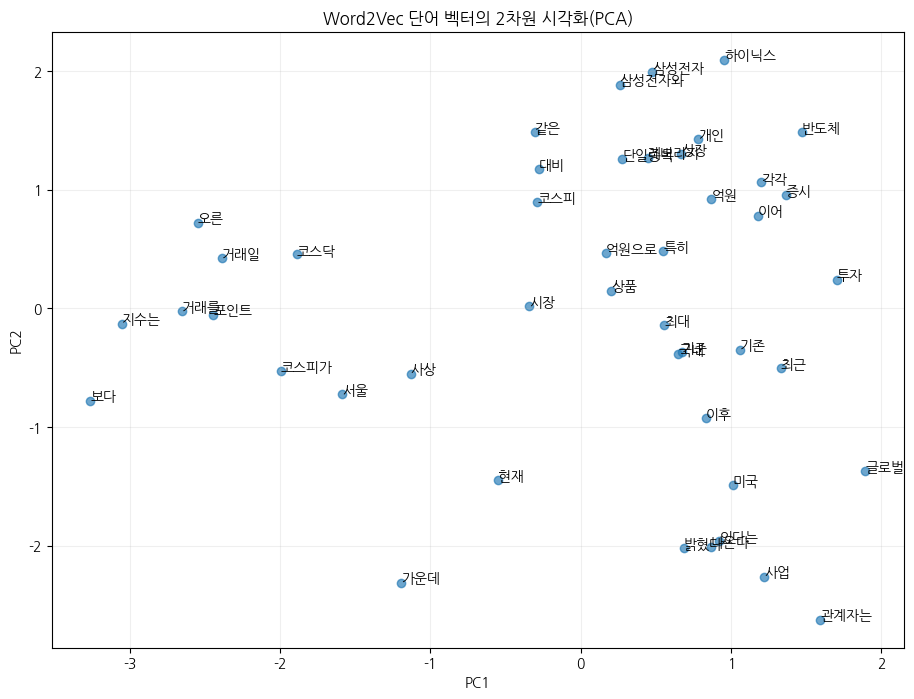

In [27]:
plt.figure(figsize=(11, 8))  # 그래프 크기를 설정합니다.
plt.scatter(coords[:, 0], coords[:, 1], alpha=0.65)  # 단어 좌표를 산점도로 표시합니다.

# 각 점 옆에 실제 단어를 표시합니다.
for word, (x, y) in zip(top_words, coords):  # 단어와 2차원 좌표를 하나씩 함께 꺼냅니다.
    plt.text(x, y, word, fontsize=10)  # 단어 라벨을 해당 좌표에 씁니다.

plt.title("Word2Vec 단어 벡터의 2차원 시각화(PCA)")  # 그래프 제목을 설정합니다.
plt.xlabel("PC1")  # x축 이름을 설정합니다.
plt.ylabel("PC2")  # y축 이름을 설정합니다.
plt.grid(alpha=0.2)  # 좌표 위치를 보기 쉽게 옅은 격자를 추가합니다.
plt.show()  # 그래프를 화면에 출력합니다.


## 4. 언어 모델은 어떤 문제를 풀며 학습할까?

Word2Vec 다음 단계의 모델 구조를 자세히 배우지는 않습니다.  
여기서는 언어 모델이 텍스트를 학습할 때 **문맥을 보고 자연스러운 말을 맞히는 문제를 아주 많이 푼다**는 정도만 연결해 봅니다.


#### 핵심 직관: 빈칸이나 다음 단어 맞히기

복잡한 모델 구조는 다루지 않고, 여기서는 **학습 목표의 느낌**만 가져갑니다.  
Word2Vec이 주변 단어를 이용해 단어 벡터를 만들었다면, 더 큰 언어 모델은 훨씬 많은 텍스트에서 **문맥을 보고 자연스러운 말을 맞히는 문제**를 반복해서 풉니다.

- **빈칸 맞추기:** 문장 일부를 가리고, 주변 문맥을 보고 빈칸에 들어갈 말을 맞힙니다.  
  - 예: `"나는 오늘 ___에 가서 돈을 입금했다"` → 주변의 `돈`, `입금`을 보고 `은행`을 떠올리는 방식입니다.
- **다음 단어 맞추기:** 앞에 나온 문맥을 보고 다음에 올 말이 무엇일지 맞힙니다.  
  - 예: `"오늘 환율이 크게"` 다음에는 `상승했다`, `하락했다` 같은 표현이 올 수 있습니다.
- 핵심은 사람이 모든 정답을 직접 붙이지 않아도, 뉴스·문서·책 같은 텍스트 자체를 학습 문제로 바꿀 수 있다는 점입니다.
- 이런 문제를 아주 큰 규모로 반복하면, 단어 의미와 문장 흐름이 숫자 표현에 조금씩 반영됩니다.

수식보다 **"문맥을 보고 맞히는 학습 → 문맥을 반영한 표현"** 이라는 연결만 기억하면 충분합니다.

#### 정리
- **원-핫 인코딩**: 단어 구분만 가능, 유사성 반영 불가  
- **통계 기반 벡터화**: 빈도·중요도·순서를 반영하지만, 의미는 여전히 부족  
- **Word2Vec 임베딩**: 주변 단어가 비슷한 단어끼리 비슷한 숫자 벡터로 표현  
- **언어 모델 학습 직관**: 문맥을 보고 빈칸이나 다음 단어를 맞히는 문제를 큰 규모로 반복함


#### 전체 흐름 정리: 한계를 보완해 온 방향

지금까지 배운 텍스트 표현 방법은 앞선 방식의 한계를 보완하는 방향으로 발전했습니다.

| 단계 | 대표 방법 | 해결하려는 문제 | 남는 한계 |
|------|-----------|----------------|----------|
| 단어 구분 | 정수 인코딩, 원-핫 인코딩 | 텍스트를 숫자로 바꿈 | 의미와 유사성 반영 불가 |
| 단어 빈도 반영 | BoW | 문서에 어떤 단어가 많이 나왔는지 표현 | 순서와 문맥 무시 |
| 단어 중요도 반영 | TF-IDF | 너무 흔한 단어의 영향 줄이기 | 깊은 의미와 유사성은 부족 |
| 짧은 순서 반영 | N-gram | 연속된 단어 패턴 일부 반영 | 차원 수 증가 |
| 의미 학습 | Word2Vec 등 임베딩 | 주변 단어가 비슷한 단어끼리 비슷한 벡터로 표현 | 학습 데이터와 토큰화 품질에 영향을 받음 |

정리하면, 이 장의 흐름은 **단순히 숫자로 구분하기 → 단어 빈도 세기 → 단어 중요도 계산하기 → 짧은 순서 반영하기 → 의미를 벡터 공간에 학습하기** 입니다.

## 5. 텍스트 분류 미니 프로젝트

짧은 리뷰 문장을 사용해 CountVectorizer와 TF-IDF가 문장을 어떤 숫자 행렬로 바꾸는지 확인합니다.

- 진행 내용: `전처리 -> 벡터화 -> 간단한 해석` 흐름을 확인합니다.
- 사용 도구: `CountVectorizer`, `TfidfVectorizer`, `LogisticRegression`

<img src="image/text_classification_pipeline.svg" width="760">

이미지 출처: 김민수 강사


In [28]:
import pandas as pd  # 표 형태 데이터를 다루는 라이브러리입니다.

reviews = [  # 감성 분류 흐름을 확인하기 위한 작은 예시 데이터입니다.
    ("배송이 빨라서 만족합니다", 1),  # 긍정 리뷰 예시입니다.
    ("포장이 깔끔하고 품질도 좋아요", 1),  # 긍정 리뷰 예시입니다.
    ("생각보다 성능이 좋아서 추천합니다", 1),  # 긍정 리뷰 예시입니다.
    ("가격 대비 괜찮은 선택이었어요", 1),  # 긍정 리뷰 예시입니다.
    ("다시 사고 싶지 않을 만큼 아쉬워요", 0),  # 부정 리뷰 예시입니다.
    ("설명과 달라서 많이 실망했습니다", 0),  # 부정 리뷰 예시입니다.
    ("배송이 늦고 응대도 아쉬웠어요", 0),  # 부정 리뷰 예시입니다.
    ("품질이 기대보다 떨어집니다", 0),  # 부정 리뷰 예시입니다.
]

df = pd.DataFrame(reviews, columns=["text", "label"])  # 데이터프레임을 직접 만듭니다.
df  # 만든 데이터프레임을 확인합니다.


,text,label
0,배송이 빨라서 만족합니다,1
1,포장이 깔끔하고 품질도 좋아요,1
2,생각보다 성능이 좋아서 추천합니다,1
3,가격 대비 괜찮은 선택이었어요,1
4,다시 사고 싶지 않을 만큼 아쉬워요,0
5,설명과 달라서 많이 실망했습니다,0
6,배송이 늦고 응대도 아쉬웠어요,0
7,품질이 기대보다 떨어집니다,0


### 문제 8. CountVectorizer로 문장 행렬 만들기

위의 `df["text"]`를 `CountVectorizer`로 변환하고, 단어 목록과 문서-단어 행렬을 확인해 보세요.

<details>
<summary>정답 보기</summary>

```python
# 풀이 흐름: 입력 데이터와 정답 데이터를 준비합니다.
# 모델이나 변환기를 적용한 뒤 결과를 확인합니다.

from sklearn.feature_extraction.text import CountVectorizer  # 문장을 단어 개수 벡터로 바꾸는 도구입니다.

count_vectorizer = CountVectorizer()  # 단어 빈도 벡터화 객체입니다.
X_count = count_vectorizer.fit_transform(df["text"])  # 학습과 변환을 한 번에 수행합니다.

print(count_vectorizer.get_feature_names_out())  # 결과를 화면에 출력합니다.
print(X_count.toarray())  # 결과를 화면에 출력합니다.

```
</details>


In [29]:
from sklearn.feature_extraction.text import CountVectorizer  # 단어 빈도 벡터화 도구입니다.

# 여기에 작성하세요

### 문제 9. TfidfVectorizer로 다시 표현하기

같은 데이터를 `TfidfVectorizer`로 바꾸고, `CountVectorizer`와 어떤 차이가 보이는지 확인해 보세요.

<details>
<summary>정답 보기</summary>

```python
# 풀이 흐름: 입력 데이터와 정답 데이터를 준비합니다.
# 모델이나 변환기를 적용한 뒤 결과를 확인합니다.

from sklearn.feature_extraction.text import TfidfVectorizer  # 문장을 TF-IDF 벡터로 바꾸는 도구입니다.

tfidf_vectorizer = TfidfVectorizer()  # TF-IDF 벡터화 객체입니다.
X_tfidf = tfidf_vectorizer.fit_transform(df["text"])  # 학습과 변환을 한 번에 수행합니다.

print(tfidf_vectorizer.get_feature_names_out())  # 결과를 화면에 출력합니다.
print(X_tfidf.toarray())  # 결과를 화면에 출력합니다.

```
</details>


In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer  # TF-IDF 벡터화 도구입니다.

# 여기에 작성하세요


### 추가 문제. 분류 결과에 영향을 많이 준 단어 확인하기

TF-IDF로 벡터화한 뒤 로지스틱 회귀를 학습하고, 긍정/부정 예측에 큰 영향을 준 단어를 확인해 보세요.

<details>
<summary>정답 보기</summary>

```python
# 풀이 흐름: 입력 데이터와 정답 데이터를 준비합니다.
# 모델이나 변환기를 적용한 뒤 결과를 확인합니다.

from sklearn.feature_extraction.text import TfidfVectorizer  # 문장을 TF-IDF 벡터로 바꾸는 도구입니다.
from sklearn.linear_model import LogisticRegression  # 단어 영향도를 확인할 선형 분류 모델입니다.

vectorizer = TfidfVectorizer()  # 문장을 숫자 벡터로 바꾸는 객체입니다.
X = vectorizer.fit_transform(df["text"])  # 학습과 변환을 한 번에 수행합니다.
y = df["label"]  # 정답 값 또는 두 번째 배열을 준비합니다.

clf = LogisticRegression(max_iter=1000, random_state=42)  # 로지스틱 회귀입니다. max_iter는 최대 반복입니다.
clf.fit(X, y)  # 데이터로 모델이나 변환 기준을 학습합니다.

feature_names = vectorizer.get_feature_names_out()  # 벡터화된 단어 목록을 가져옵니다.
coef = clf.coef_[0]  # 각 단어의 분류 가중치를 가져옵니다.

top_positive = coef.argsort()[-5:][::-1]  # 긍정 방향 가중치가 큰 단어 인덱스입니다.
top_negative = coef.argsort()[:5]  # 부정 방향 가중치가 큰 단어 인덱스입니다.

print("긍정에 가까운 단어:", feature_names[top_positive])  # 결과를 화면에 출력합니다.
print("부정에 가까운 단어:", feature_names[top_negative])  # 결과를 화면에 출력합니다.

```
</details>


In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer  # 문장을 TF-IDF 벡터로 바꾸는 도구입니다.
from sklearn.linear_model import LogisticRegression  # 단어 영향도를 확인할 선형 분류 모델입니다.

# 여기에 작성하세요


In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer  # 문장을 TF-IDF 벡터로 바꾸는 도구입니다.
from sklearn.linear_model import LogisticRegression  # 단어 영향도를 확인할 선형 분류 모델입니다.

vectorizer = TfidfVectorizer()  # 문장을 숫자 벡터로 바꾸는 객체입니다.
X = vectorizer.fit_transform(df["text"])  # 학습과 변환을 한 번에 수행합니다.
y = df["label"]  # 정답 값 또는 두 번째 배열을 준비합니다.

clf = LogisticRegression(max_iter=1000, random_state=42)  # 로지스틱 회귀입니다. max_iter는 최대 반복입니다.
clf.fit(X, y)  # 데이터로 모델이나 변환 기준을 학습합니다.

feature_names = vectorizer.get_feature_names_out()  # 벡터화된 단어 목록을 가져옵니다.
coef = clf.coef_[0]  # 각 단어의 분류 가중치를 가져옵니다.

top_positive = coef.argsort()[-5:][::-1]  # 긍정 방향 가중치가 큰 단어 인덱스입니다.
top_negative = coef.argsort()[:5]  # 부정 방향 가중치가 큰 단어 인덱스입니다.

print("긍정에 가까운 단어:", feature_names[top_positive])  # 결과를 화면에 출력합니다.
print("부정에 가까운 단어:", feature_names[top_negative])  # 결과를 화면에 출력합니다.

긍정에 가까운 단어: ['빨라서' '만족합니다' '품질도' '좋아서' '좋아요']
부정에 가까운 단어: ['기대보다' '떨어집니다' '품질이' '늦고' '아쉬웠어요']


## 6. 실제 영화리뷰 감성 분류 실습: NSMC

이번에는 실제 리뷰 데이터인 **네이버 영화리뷰 감성분석 데이터(NSMC)** 를 사용해 감성 분류 모델을 만들어 봅니다.

- 원본 데이터: https://github.com/e9t/nsmc  
- 데이터 파일: `data/ratings_train.txt`, `data/ratings_test.txt`  
- 입력 데이터: 영화 리뷰 문장  
- 정답 라벨: `0`은 부정, `1`은 긍정  
- 진행 내용: 간단한 EDA와 정제를 거친 뒤, TF-IDF 벡터와 로지스틱 회귀로 새 리뷰의 감성을 예측합니다.

실제 리뷰는 표현이 다양하므로 TF-IDF 벡터의 크기가 너무 커질 수 있습니다. 그래서 `max_features`, `min_df`, `max_df`로 벡터 크기를 통제합니다.


### 6.1 데이터 불러오기

먼저 학습용 파일과 테스트용 파일을 각각 읽어 옵니다. NSMC 파일은 열이 탭(`\t`)으로 구분된 텍스트 파일입니다.


In [33]:
import pandas as pd  # 표 형태 데이터를 다루는 라이브러리입니다.
import matplotlib.pyplot as plt  # 그래프를 그리는 시각화 도구입니다.

# read_csv는 CSV뿐 아니라 구분자가 있는 텍스트 파일도 읽을 수 있습니다.
# sep="\t"는 열이 쉼표가 아니라 탭 문자로 구분되어 있다는 뜻입니다.
train_df = pd.read_csv("data/ratings_train.txt", sep="\t")  # 학습용 리뷰 데이터입니다.
test_df = pd.read_csv("data/ratings_test.txt", sep="\t")  # 최종 평가용 리뷰 데이터입니다.


In [34]:
# head()는 데이터 앞부분 5행을 보여줍니다.
# id: 리뷰 번호, document: 리뷰 문장, label: 정답 라벨입니다.
train_df.head()  # 학습 데이터 앞부분을 확인합니다.


,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1


### 6.2 간단한 EDA

모델을 만들기 전에 데이터 크기, 결측치, 중복, 라벨 분포를 확인합니다. 텍스트 데이터에서는 빈 리뷰나 중복 리뷰가 섞이는 경우가 많습니다.


In [35]:
# shape는 데이터프레임의 (행 개수, 열 개수)를 알려줍니다.
print("train 크기:", train_df.shape)  # 학습 데이터의 행과 열 개수를 출력합니다.
print("test 크기:", test_df.shape)  # 테스트 데이터의 행과 열 개수를 출력합니다.


train 크기: (150000, 3)
test 크기: (50000, 3)


In [36]:
# DataFrame({...})은 딕셔너리 형태의 데이터를 표로 만드는 문법입니다.
# len(...)은 행 개수, isna().sum()은 결측치 개수, duplicated().sum()은 중복 개수를 셉니다.
summary = pd.DataFrame({  # 학습/테스트 데이터의 기본 상태를 요약하는 표를 만듭니다.
    "train": [  # 학습 데이터 요약값입니다.
        len(train_df),  # 전체 학습 데이터 행 수입니다.
        train_df["document"].isna().sum(),  # 리뷰 문장이 비어 있는 행 수입니다.
        train_df["document"].duplicated().sum(),  # 같은 리뷰 문장이 반복된 행 수입니다.
        (train_df["label"] == 1).sum(),  # label이 1인 긍정 리뷰 수입니다.
        (train_df["label"] == 0).sum(),  # label이 0인 부정 리뷰 수입니다.
    ],
    "test": [  # 테스트 데이터 요약값입니다.
        len(test_df),  # 전체 테스트 데이터 행 수입니다.
        test_df["document"].isna().sum(),  # 테스트 리뷰 문장이 비어 있는 행 수입니다.
        test_df["document"].duplicated().sum(),  # 테스트 데이터의 중복 리뷰 수입니다.
        (test_df["label"] == 1).sum(),  # 테스트 데이터의 긍정 리뷰 수입니다.
        (test_df["label"] == 0).sum(),  # 테스트 데이터의 부정 리뷰 수입니다.
    ],
}, index=["전체 행", "리뷰 결측", "리뷰 중복", "긍정 리뷰", "부정 리뷰"])  # 요약 표의 행 이름을 지정합니다.

summary  # 데이터 요약 표를 확인합니다.


,train,test
전체 행,150000,50000
리뷰 결측,5,3
리뷰 중복,3817,842
긍정 리뷰,74827,25173
부정 리뷰,75173,24827


In [37]:
# map({0: "부정", 1: "긍정"})은 숫자 라벨을 사람이 읽기 쉬운 글자로 바꿉니다.
# value_counts()는 값별 개수를 세어 라벨 균형을 확인할 때 자주 씁니다.
label_counts = train_df["label"].map({0: "부정", 1: "긍정"}).value_counts()  # 학습 데이터의 긍정/부정 개수를 셉니다.
label_counts  # 라벨 분포를 확인합니다.


label
부정    75173
긍정    74827
Name: count, dtype: int64

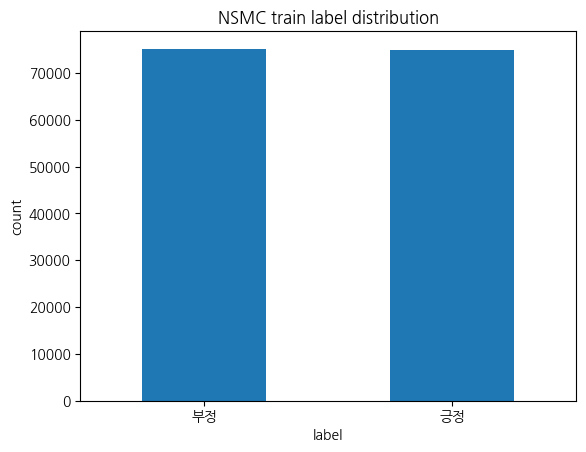

In [38]:
# plot(kind="bar")는 막대그래프를 그립니다.
# rot=0은 x축 글자가 기울어지지 않도록 설정합니다.
label_counts.plot(kind="bar", rot=0)  # 라벨 개수를 막대그래프로 그립니다.
plt.title("NSMC train label distribution")  # 그래프 제목을 설정합니다.
plt.xlabel("label")  # x축 이름을 설정합니다.
plt.ylabel("count")  # y축 이름을 설정합니다.
plt.show()  # 그래프를 화면에 출력합니다.


### 6.3 텍스트 정제

리뷰에는 특수문자, 반복 기호, 빈 문자열이 섞여 있습니다. 여기서는 모델 실습에 필요한 최소 정제만 적용합니다.


In [39]:
import re  # 정규표현식을 사용하기 위한 모듈입니다.

# def는 함수를 만드는 문법입니다. 같은 정제 과정을 여러 문장에 반복 적용하기 위해 함수로 묶습니다.
def clean_review(text):  # 리뷰 문장 하나를 입력받아 분석에 사용할 형태로 정제하는 함수입니다.
    text = str(text)  # 혹시 숫자나 결측값이 들어와도 문자열로 바꿔 처리합니다.
    # re.sub(패턴, 바꿀값, 텍스트)는 패턴에 맞는 부분을 다른 값으로 바꿉니다.
    # 아래 패턴은 한글, 영문, 숫자, 공백이 아닌 문자를 공백으로 바꿉니다.
    text = re.sub(r"[^가-힣a-zA-Z0-9\s]", " ", text)  # 한글, 영문, 숫자, 공백이 아닌 문자를 공백으로 바꿉니다.
    # \s+는 공백이 1개 이상 반복되는 경우를 뜻합니다. 여러 공백을 하나로 줄입니다.
    text = re.sub(r"\s+", " ", text).strip()  # 여러 공백을 하나로 줄이고 앞뒤 공백을 제거합니다.
    return text  # 정제된 리뷰 문장을 반환합니다.


In [40]:
# 정제 함수가 어떻게 동작하는지 짧은 예시로 먼저 확인합니다.
sample_text = "와... 이 영화ㅋㅋ 진짜!!! 최고네요~~~"  # 정제 결과를 확인할 예시 문장입니다.
clean_review(sample_text)  # 예시 문장에 정제 함수를 적용합니다.


'와 이 영화 진짜 최고네요'

In [41]:
# dropna(subset=[...])는 지정한 열에 결측치가 있는 행을 제거합니다.
# drop_duplicates(subset=[...])는 지정한 열 기준으로 중복 행을 제거합니다.
# copy()는 원본 데이터프레임을 건드리지 않고 새로운 복사본을 만들기 위해 사용합니다.
train_clean = train_df.dropna(subset=["document"]).drop_duplicates(subset=["document"]).copy()  # 학습 데이터에서 빈 리뷰와 중복 리뷰를 제거합니다.
test_clean = test_df.dropna(subset=["document"]).drop_duplicates(subset=["document"]).copy()  # 테스트 데이터에서 빈 리뷰와 중복 리뷰를 제거합니다.

print("정제 전 train 행 수:", len(train_df))  # 정제 전 학습 데이터 크기를 출력합니다.
print("결측/중복 제거 후 train 행 수:", len(train_clean))  # 정제 후 학습 데이터 크기를 출력합니다.


정제 전 train 행 수: 150000
결측/중복 제거 후 train 행 수: 146182


In [42]:
# map(함수)는 Series의 각 값에 함수를 하나씩 적용합니다.
# document 원문을 정제한 결과를 text라는 새 열에 저장합니다.
train_clean["text"] = train_clean["document"].map(clean_review)  # 학습 리뷰 원문을 정제해 text 열에 저장합니다.
test_clean["text"] = test_clean["document"].map(clean_review)  # 테스트 리뷰 원문을 정제해 text 열에 저장합니다.

# str.len()은 문자열 길이를 계산합니다.
# 길이가 0인 리뷰는 모델에 사용할 정보가 없으므로 제거합니다.
train_clean = train_clean[train_clean["text"].str.len() > 0].reset_index(drop=True)  # 정제 후 빈 문자열이 된 학습 리뷰를 제거합니다.
test_clean = test_clean[test_clean["text"].str.len() > 0].reset_index(drop=True)  # 정제 후 빈 문자열이 된 테스트 리뷰를 제거합니다.

# label_name은 그래프나 표에서 라벨을 읽기 쉽게 보기 위한 보조 열입니다.
train_clean["label_name"] = train_clean["label"].map({0: "부정", 1: "긍정"})  # 숫자 라벨을 읽기 쉬운 이름으로 바꿉니다.
train_clean["review_length"] = train_clean["text"].str.len()  # 정제된 리뷰 문장의 길이를 계산합니다.

train_clean[["document", "text", "label_name"]].head()  # 원문, 정제 결과, 라벨을 함께 확인합니다.


,document,text,label_name
0,아 더빙.. 진짜 짜증나네요 목소리,아 더빙 진짜 짜증나네요 목소리,부정
1,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,흠 포스터보고 초딩영화줄 오버연기조차 가볍지 않구나,긍정
2,너무재밓었다그래서보는것을추천한다,너무재밓었다그래서보는것을추천한다,부정
3,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,교도소 이야기구먼 솔직히 재미는 없다 평점 조정,부정
4,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,사이몬페그의 익살스런 연기가 돋보였던 영화 스파이더맨에서 늙어보이기만 했던 커스틴 ...,긍정


In [43]:
# groupby("label_name")은 라벨별로 데이터를 묶습니다.
# describe()는 개수, 평균, 표준편차, 사분위수 같은 요약 통계를 보여줍니다.
train_clean.groupby("label_name")["review_length"].describe().round(2)  # 라벨별 리뷰 길이 요약 통계를 확인합니다.


,count,mean,std,min,25%,50%,75%,max
label_name,,,,,,,,
긍정,72739.0,32.78,27.64,1.0,15.0,25.0,40.0,140.0
부정,73200.0,33.78,29.14,1.0,15.0,25.0,40.0,140.0


### 6.4 TF-IDF 벡터 크기 통제하기

실제 리뷰 데이터는 단어와 표현이 매우 다양합니다. `ngram_range=(1, 2)`를 무제한으로 사용하면 벡터 차원이 과하게 커질 수 있으므로 아래 옵션으로 크기를 제한합니다.

| 옵션 | 의미 |
|------|------|
| `max_features=15000` | 최대 15,000개 표현만 사용합니다. |
| `min_df=3` | 3개 미만 문서에만 등장한 너무 드문 표현은 제거합니다. |
| `max_df=0.9` | 전체 문서의 90% 이상에 등장하는 너무 흔한 표현은 제거합니다. |
| `ngram_range=(1, 2)` | 단어 1개와 2개 조합까지만 사용합니다. |

수업 시간을 고려해 기본 학습 데이터는 50,000개로 제한합니다. 더 정확한 모델을 만들고 싶다면 `train_size`를 늘려 보세요.


In [44]:
from sklearn.feature_extraction.text import TfidfVectorizer  # 문장을 TF-IDF 벡터로 바꾸는 도구입니다.
from sklearn.linear_model import LogisticRegression  # 분류에 사용할 로지스틱 회귀 모델입니다.
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report  # 평가 결과를 확인하는 도구입니다.

In [45]:
# 전체 데이터를 모두 써도 되지만, 수업 실습에서는 실행 시간을 줄이기 위해 일부만 사용합니다.
train_size = 50_000  # 학습에 사용할 리뷰 수를 50,000개로 정합니다.
test_size = 20_000  # 평가에 사용할 리뷰 수를 20,000개로 정합니다.

# sample(n=...)은 데이터에서 n개 행을 무작위로 뽑습니다.
# random_state는 무작위 추출 결과가 매번 같아지도록 고정하는 값입니다.
train_model_df = train_clean.sample(n=train_size, random_state=42).reset_index(drop=True)  # 학습용 리뷰를 무작위로 추출합니다.
test_model_df = test_clean.sample(n=test_size, random_state=42).reset_index(drop=True)  # 평가용 리뷰를 무작위로 추출합니다.

print("학습에 사용할 리뷰 수:", len(train_model_df))  # 실제 학습에 들어가는 리뷰 수를 출력합니다.
print("평가에 사용할 리뷰 수:", len(test_model_df))  # 실제 평가에 들어가는 리뷰 수를 출력합니다.


학습에 사용할 리뷰 수: 50000
평가에 사용할 리뷰 수: 20000


In [46]:
# 먼저 TF-IDF 벡터화 객체를 따로 만듭니다.
# 이 객체는 텍스트에서 단어/표현 목록을 학습하고, 각 리뷰를 숫자 벡터로 바꿉니다.
tfidf_vectorizer = TfidfVectorizer(  # 리뷰 문장을 TF-IDF 벡터로 바꾸는 객체를 만듭니다.
    max_features=15_000,  # 벡터 차원을 최대 15,000개 표현으로 제한합니다.
    min_df=3,  # 3개 미만 리뷰에만 등장한 너무 드문 표현은 제외합니다.
    max_df=0.9,  # 전체 리뷰의 90% 이상에 등장한 너무 흔한 표현은 제외합니다.
    ngram_range=(1, 2),  # 단어 1개와 2개 조합을 함께 사용합니다.
)

# 그 다음 분류 모델을 따로 만듭니다.
sentiment_model = LogisticRegression(  # TF-IDF 벡터를 입력으로 받을 분류 모델을 만듭니다.
    random_state=42,  # 실습 결과가 비슷하게 나오도록 난수 기준을 고정합니다.
)

tfidf_vectorizer, sentiment_model  # 생성된 벡터화 객체와 분류 모델을 확인합니다.

(TfidfVectorizer(max_df=0.9, max_features=15000, min_df=3, ngram_range=(1, 2)),
 LogisticRegression(random_state=42))

In [47]:
# fit_transform은 학습 데이터에서 단어 사전을 학습하고, 학습 리뷰를 숫자 벡터로 바꿉니다.
X_train_tfidf = tfidf_vectorizer.fit_transform(train_model_df["text"])  # 학습 리뷰를 TF-IDF 행렬로 변환합니다.

# transform은 이미 학습한 단어 사전을 기준으로 평가 리뷰를 숫자 벡터로 바꿉니다.
# 평가 데이터에는 fit을 다시 하지 않습니다. 그래야 학습/평가 기준이 같아집니다.
X_test_tfidf = tfidf_vectorizer.transform(test_model_df["text"])  # 평가 리뷰를 같은 기준의 TF-IDF 행렬로 변환합니다.

In [48]:
# fit(입력 벡터, 정답)은 로지스틱 회귀 모델을 학습합니다.
sentiment_model.fit(X_train_tfidf, train_model_df["label"])  # TF-IDF 벡터와 정답 라벨로 분류 모델을 학습합니다.

# predict(입력 벡터)는 학습된 모델로 새 리뷰의 라벨을 예측합니다.
pred = sentiment_model.predict(X_test_tfidf)  # 평가 리뷰의 감성 라벨을 예측합니다.

pred[:10]  # 예측 결과 앞 10개만 확인합니다.

array([0, 0, 0, 0, 1, 0, 0, 1, 0, 0])

In [49]:
# get_feature_names_out()은 TF-IDF가 만든 단어/표현 목록을 가져옵니다.
feature_count = len(tfidf_vectorizer.get_feature_names_out())  # 모델이 사용한 단어/표현 개수를 계산합니다.

print("TF-IDF 벡터 차원:", feature_count)  # TF-IDF 행렬의 열 개수를 출력합니다.
print("accuracy:", accuracy_score(test_model_df["label"], pred))  # 전체 정확도를 출력합니다.

# classification_report는 precision, recall, f1-score를 한 번에 보여줍니다.
print(classification_report(test_model_df["label"], pred, target_names=["부정", "긍정"]))  # 라벨별 평가 지표를 출력합니다.


TF-IDF 벡터 차원: 15000
accuracy: 0.78675
              precision    recall  f1-score   support

          부정       0.76      0.83      0.80      9949
          긍정       0.82      0.74      0.78     10051

    accuracy                           0.79     20000
   macro avg       0.79      0.79      0.79     20000
weighted avg       0.79      0.79      0.79     20000



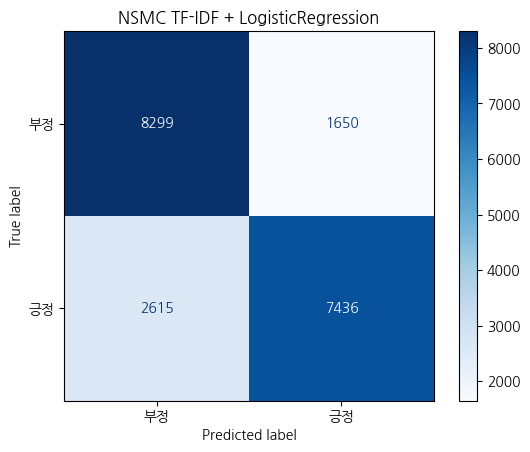

In [50]:
# ConfusionMatrixDisplay는 실제 라벨과 예측 라벨이 어떻게 맞고 틀렸는지 표 형태로 보여줍니다.
ConfusionMatrixDisplay.from_predictions(  # 실제 라벨과 예측 라벨의 혼동행렬을 그립니다.
    test_model_df["label"],  # 실제 정답 라벨입니다.
    pred,  # 모델이 예측한 라벨입니다.
    display_labels=["부정", "긍정"],  # 그래프에 표시할 라벨 이름입니다.
    cmap="Blues",  # 혼동행렬 색상 팔레트입니다.
)
plt.title("NSMC TF-IDF + LogisticRegression")  # 그래프 제목을 설정합니다.
plt.show()  # 그래프를 화면에 출력합니다.


### 6.5 직접 쓴 리뷰 예측하기

학습한 모델에 새로운 리뷰 문장을 넣어 긍정/부정을 예측해 봅니다.


In [51]:
# 이 함수는 리뷰 한 문장을 받아 정제 -> 예측 -> 결과 정리까지 수행합니다.
def predict_review(review):  # 새 리뷰 한 문장의 감성을 예측하는 함수입니다.
    cleaned = clean_review(review)  # 학습 데이터와 같은 방식으로 입력 문장을 정제합니다.
    # 새 리뷰도 학습 때 만든 TF-IDF 기준으로 숫자 벡터로 바꿔야 합니다.
    review_tfidf = tfidf_vectorizer.transform([cleaned])  # 정제된 리뷰를 TF-IDF 벡터로 변환합니다.
    # predict_proba는 각 클래스일 확률을 반환합니다. [0]은 첫 번째 문장의 결과를 꺼내는 뜻입니다.
    proba = sentiment_model.predict_proba(review_tfidf)[0]  # 부정/긍정 확률을 계산합니다.
    # proba[1]은 긍정 클래스(라벨 1)의 확률입니다. 0.5 이상이면 긍정으로 판단합니다.
    pred_label = int(proba[1] >= 0.5)  # 긍정 확률이 0.5 이상이면 긍정 라벨로 정합니다.
    return {  # 예측 결과를 딕셔너리 형태로 반환합니다.
        "review": review,  # 입력 리뷰 원문입니다.
        "prediction": "긍정" if pred_label == 1 else "부정",  # 예측한 감성 이름입니다.
        "positive_probability": round(float(proba[1]), 3),  # 긍정 클래스 확률을 소수 셋째 자리까지 표시합니다.
    }


In [52]:
sample_reviews = [  # 학습된 모델에 넣어 볼 새 리뷰 목록입니다.
    "배우 연기는 좋았지만 스토리가 너무 지루했다",  # 부정에 가까운 예시 문장입니다.
    "시간 가는 줄 모르고 봤다 정말 추천한다",  # 긍정에 가까운 예시 문장입니다.
    "돈이 아까운 영화였다",  # 부정에 가까운 예시 문장입니다.
    "음악과 연출이 좋아서 다시 보고 싶다",  # 긍정에 가까운 예시 문장입니다.
]

# 리스트 컴프리헨션은 리스트 안에서 반복문을 짧게 쓰는 문법입니다.
# 아래 코드는 sample_reviews의 각 리뷰에 predict_review를 적용해 결과 리스트를 만듭니다.
pd.DataFrame([predict_review(review) for review in sample_reviews])  # 예측 결과를 표로 정리합니다.


,review,prediction,positive_probability
0,배우 연기는 좋았지만 스토리가 너무 지루했다,부정,0.168
1,시간 가는 줄 모르고 봤다 정말 추천한다,긍정,0.700
2,돈이 아까운 영화였다,부정,0.119
3,음악과 연출이 좋아서 다시 보고 싶다,긍정,0.933


### 6.6 모델이 중요하게 본 표현 확인하기

로지스틱 회귀는 각 단어/표현에 가중치를 부여합니다. 가중치가 크면 긍정 예측에, 작으면 부정 예측에 더 강하게 작용합니다.


In [53]:
# 학습된 TF-IDF 변환기와 로지스틱 회귀 모델에서 필요한 값을 직접 꺼냅니다.
feature_names = tfidf_vectorizer.get_feature_names_out()  # 모델이 사용한 단어/표현 목록입니다.
coef = sentiment_model.coef_[0]  # 로지스틱 회귀가 학습한 각 표현의 가중치입니다.

print("표현 개수:", len(feature_names))  # TF-IDF 표현 개수를 출력합니다.
print("가중치 개수:", len(coef))  # 로지스틱 회귀 가중치 개수를 출력합니다.


표현 개수: 15000
가중치 개수: 15000


In [54]:
coef.shape

(15000,)

In [55]:
# argsort()는 값을 작은 순서대로 정렬했을 때의 인덱스를 반환합니다.
# coef.argsort()[-15:][::-1]은 가중치가 큰 표현 15개를 큰 순서대로 가져오는 문법입니다.
positive_index = coef.argsort()[-15:][::-1]  # 긍정 방향 가중치가 큰 표현의 인덱스를 고릅니다.
negative_index = coef.argsort()[:15]  # 부정 방향 가중치가 큰 표현의 인덱스를 고릅니다.

top_positive = pd.DataFrame({  # 긍정 방향 상위 표현을 표로 만듭니다.
    "word": feature_names[positive_index],  # 긍정 예측에 강하게 연결된 표현입니다.
    "weight": coef[positive_index],  # 각 표현의 긍정 방향 가중치입니다.
})

top_negative = pd.DataFrame({  # 부정 방향 상위 표현을 표로 만듭니다.
    "word": feature_names[negative_index],  # 부정 예측에 강하게 연결된 표현입니다.
    "weight": coef[negative_index],  # 각 표현의 부정 방향 가중치입니다.
})

print("긍정 예측에 영향을 많이 준 표현")  # 긍정 방향 표현 표의 제목을 출력합니다.
display(top_positive)  # 긍정 방향 상위 표현을 표로 보여줍니다.

print("부정 예측에 영향을 많이 준 표현")  # 부정 방향 표현 표의 제목을 출력합니다.
display(top_negative)  # 부정 방향 상위 표현을 표로 보여줍니다.


긍정 예측에 영향을 많이 준 표현


,word,weight
0,최고의,5.080633
1,최고,4.710425
2,여운이,4.203748
3,아름다운,4.017053
4,명작,3.641602
5,재밌어요,3.610410
6,최고다,3.598714
7,재밌다,3.569427
8,재미있어요,3.482161
9,가슴이,3.461472


부정 예측에 영향을 많이 준 표현


,word,weight
0,최악의,-5.333915
1,쓰레기,-4.833605
2,아깝다,-4.805757
3,최악,-4.548758
4,지루하다,-4.087202
5,재미없다,-3.925556
6,별로,-3.922777
7,차라리,-3.913951
8,지루하고,-3.788185
9,졸작,-3.784990


## 체크포인트

- 텍스트 전처리 방법은 데이터 목적에 따라 달라집니다.
- BoW, TF-IDF, Word2Vec은 모두 텍스트를 수치화하는 방법이지만 표현 방식과 장단점이 다릅니다.
- 딥러닝 모델을 쓰지 않아도 `벡터화 + 선형 모델`만으로 텍스트 분류의 기본 흐름을 만들 수 있습니다.
- 실제 리뷰 데이터에서는 `max_features`, `min_df`, `max_df`로 TF-IDF 벡터 크기를 통제해야 합니다.
